<a href="https://colab.research.google.com/github/AntonDozhdikov/politpredict/blob/main/Super_MARL_EVO_Communication_v12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Super MARL EVO Communication — BRICS v12 (MARL_BRICS_COM)

Многоагентное обучение с подкреплением (MATD3) и саморефлексивный ИИ (Meta-Weight Adapter, Meta-BRICS Agent)
для моделирования стратегической коммуникации БРИКС+ с учётом исторических и перспективных кризисов.

**Все результаты сохраняются на Google Drive** в папку `MARL_BRICS_COM/`.

## Пять фаз эксперимента

| Фаза | Модель | Агентов | Идея |
|---|---|---|---|
| Exp.0 | DNLSSM World Model | 0 | базовый прогноз динамики без управления |
| Exp.1 | MATD3 MARL | 10 | децентрализованная координация, фикс. веса награды |
| Exp.2.1 | MWA (Россия) | 10 | саморефлексия у одного агента |
| Exp.2.2 | MWA (все) + alignment | 10 | распределённая саморефлексия с согласованием |
| Exp.2.3 | Meta-BRICS Agent | 10+1 | наднациональная иерархическая координация |

## Кризисы и сценарии (кратко)

Обучение идёт **сразу с 25 историческими кризисами** (1993–2023, все 7 типов); тестирование — на **30 перспективных
кризисах (2026–2031)**, ранее моделью не виденных, объединённых в **10 тестовых сценариев** (по 3 кризиса на сценарий).

## Оглавление

1. Проверка среды и зависимости
2. Логгер и утилиты
3. Конфигурация (`EXPConfig`) — 600 эпизодов, ранняя остановка с warm-up
4. Google Drive: монтирование и структура папок проекта
5. Сиды и воспроизводимость
6. Загрузка и подготовка панели данных
7. State space (36) / Action space (14)
8. Каталог 55 кризисов (25 исторических + 30 перспективных) и 10 сценариев
9. Функция вознаграждения и среда `BRICSPOSGEnv`
10. World Model (Exp.0)
11. MATD3 (Exp.1): Actor/Critic/Buffer/Trainer
12. Self-Referential модули (MWA, NES) — Exp.2.1/2.2
13. Meta-BRICS Agent — Exp.2.3
14. Метрики (CumR, PolVol, ShockRec, BCI, SCI, WDiv, AC, WAR)
15. Прогресс-бар и ранняя остановка
16. Единый цикл обучения `run_marl_experiment`
17. Финальный re-run лучших конфигураций на 10 сценариях
18. Экспорт в Excel (4 файла, титульные листы, навигация)
19. Визуализация
20. Оркестратор `run_full_pipeline`
21. Сравнение запусков `compare_previous_runs`
22. **Меню запуска** (точка входа)

## 1. Проверка среды выполнения

In [1]:
import sys, platform, os
IN_COLAB = "google.colab" in sys.modules
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Colab:", IN_COLAB)
try:
    import torch
    print(f"PyTorch: {torch.__version__}, CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"  GPU: {torch.cuda.get_device_name(0)}")
except ImportError:
    print("PyTorch не установлен — будет установлен ниже.")

Python: 3.12.13
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
Colab: True
PyTorch: 2.11.0+cu128, CUDA available: True
  GPU: Tesla T4


## 2. Установка зависимостей

In [2]:
import subprocess, sys
def _pip_install(pkgs):
    for p in pkgs:
        try:
            __import__(p.split("==")[0].replace("-", "_"))
        except ImportError:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])
_pip_install(["openpyxl", "tqdm", "plotly"])
print("Зависимости готовы.")

Зависимости готовы.


## 3. Импорты, логгер, утилиты

In [3]:
import json, time, math, random, hashlib, traceback, logging, warnings, datetime
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Optional, Dict, List, Tuple, Any, Callable
from collections import defaultdict, deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class _ColorFmt(logging.Formatter):
    COLORS = {"DEBUG":"\033[36m","INFO":"\033[32m","WARNING":"\033[33m","ERROR":"\033[31m","CRITICAL":"\033[1;31m"}
    RESET = "\033[0m"
    def format(self, record):
        col = self.COLORS.get(record.levelname, "")
        base = super().format(record)
        return f"{col}{base}{self.RESET}" if col else base

def _install_logger(name="super_marl_evo"):
    lg = logging.getLogger(name)
    if lg.handlers:
        return lg
    lg.setLevel(logging.INFO)
    h = logging.StreamHandler(sys.stdout)
    h.setFormatter(_ColorFmt("[%(asctime)s | %(levelname)s] %(message)s", "%H:%M:%S"))
    lg.addHandler(h)
    return lg

LOG = _install_logger()

def log_exception(prefix=""):
    LOG.error(f"{prefix} — исключение:")
    LOG.error(traceback.format_exc())

LOG.info(f"Устройство: {DEVICE}")

[18:29:44 | INFO] Устройство: cuda


INFO:super_marl_evo:Устройство: cuda


## 4. Конфигурация эксперимента

Ключевые изменения относительно v7: 600 эпизодов (было 300), ранняя остановка с warm-up и сглаживанием,
обучение сразу с историческими кризисами (`train_with_crises_from_start=True`).

In [4]:
PROJECT_DIRNAME = "MARL_BRICS_COM"

@dataclass
class EXPConfig:
    project_name: str = "MARL_BRICS_COM"
    version: str = "v12.0"
    seeds: List[int] = field(default_factory=lambda: [17, 42, 101, 202, 303, 404, 505, 606, 707, 808])
    countries: List[str] = field(default_factory=lambda:
        ["RUS", "CHN", "IND", "BRA", "ZAF", "IRN", "ARE", "ETH", "EGY", "IDN"])
    year_min: int = 1990
    year_max: int = 2024

    n_state_features: int = 36
    n_actions: int = 14
    n_agents: int = 10

    wm_hidden: int = 128
    wm_layers: int = 3
    wm_epochs: int = 80
    wm_lr: float = 1e-3
    wm_batch: int = 64
    wm_horizon: int = 5

    marl_actor_hidden: Tuple[int, int, int] = (256, 128, 64)
    marl_critic_hidden: Tuple[int, int, int] = (256, 128, 64)
    marl_episodes: int = 600
    marl_steps_per_episode: int = 60
    marl_gamma: float = 0.97
    marl_tau: float = 0.005
    marl_lr_actor: float = 3e-4
    marl_lr_critic: float = 3e-4
    marl_batch: int = 256
    marl_buffer: int = 100_000
    marl_policy_delay: int = 2
    marl_noise: float = 0.15
    marl_target_noise: float = 0.20
    marl_target_noise_clip: float = 0.5
    marl_noise_decay_episodes: int = 200
    marl_update_every_n_steps: int = 3   # градиентный шаг раз в N шагов среды (было: каждый шаг)
    marl_updates_per_call: int = 2       # число градиентных шагов при каждом вызове update-фазы

    mwa_update_every: int = 20
    mwa_hidden: int = 64
    mwa_lr: float = 1e-3
    mwa_alignment_lambda: float = 0.10

    meta_hidden: int = 128
    meta_lr: float = 3e-4
    meta_reward_beta: float = 0.4

    early_stop_patience: int = 70
    early_stop_rel_delta: float = 0.01
    early_stop_warmup: int = 60
    early_stop_smooth_window: int = 10

    use_gpu: bool = True
    checkpoint_every: int = 25
    verbose: bool = True

    reward_w_econ: float = 0.30
    reward_w_diplo: float = 0.25
    reward_w_media: float = 0.15
    reward_w_block: float = 0.20
    reward_w_conflict_penalty: float = 0.10

    downscale_cpu: bool = True
    smoke_test: bool = False

    train_with_crises_from_start: bool = True
    training_crisis_ids: List[int] = field(default_factory=list)   # заполняется после каталога кризисов
    test_scenario_crisis_ids: List[int] = field(default_factory=list)
    shock_recovery_window: int = 5

    def effective(self):
        c = EXPConfig(**asdict(self))
        if self.smoke_test:
            c.marl_episodes = 12
            c.wm_epochs = 10
            c.seeds = self.seeds[:2]
        if self.downscale_cpu and not torch.cuda.is_available():
            c.marl_episodes = max(150, self.marl_episodes // 3)
            c.wm_epochs = max(20, self.wm_epochs // 3)
        return c

CFG = EXPConfig()
LOG.info(f"Config создан. Сиды: {CFG.seeds}")

[18:29:44 | INFO] Config создан. Сиды: [17, 42, 101, 202, 303, 404, 505, 606, 707, 808]


INFO:super_marl_evo:Config создан. Сиды: [17, 42, 101, 202, 303, 404, 505, 606, 707, 808]


## 5. Google Drive: монтирование и структура папок

Все результаты (данные, чекпоинты, логи, метрики, Excel, графики) сохраняются **только на Google Drive**
в папку `MyDrive/MARL_BRICS_COM/`.

In [5]:
def _mount_drive():
    from google.colab import drive
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive", force_remount=False)
    return Path(f"/content/drive/MyDrive/{PROJECT_DIRNAME}")

if IN_COLAB:
    ROOT = _mount_drive()
else:
    LOG.warning("Не Colab: используем локальную папку (Drive недоступен вне Colab).")
    ROOT = Path(f"./{PROJECT_DIRNAME}").resolve()

DIRS = {
    "root": ROOT, "data": ROOT/"data", "checkpoints": ROOT/"checkpoints",
    "logs": ROOT/"logs", "results": ROOT/"results", "figures": ROOT/"figures",
    "excel": ROOT/"excel", "runs": ROOT/"runs",
    "world_model": ROOT/"checkpoints"/"world_model",
    "exp1": ROOT/"checkpoints"/"exp1_marl",
    "exp21": ROOT/"checkpoints"/"exp21_selfref_russia",
    "exp22": ROOT/"checkpoints"/"exp22_selfref_all",
    "exp23": ROOT/"checkpoints"/"exp23_meta_brics",
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

LOG.info(f"Корневая папка проекта: {ROOT}")

Mounted at /content/drive
[18:30:11 | INFO] Корневая папка проекта: /content/drive/MyDrive/MARL_BRICS_COM


INFO:super_marl_evo:Корневая папка проекта: /content/drive/MyDrive/MARL_BRICS_COM


## 6. Сиды и воспроизводимость

In [6]:
def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def hash_config(cfg: "EXPConfig") -> str:
    payload = json.dumps(asdict(cfg), sort_keys=True, default=str).encode()
    return hashlib.sha256(payload).hexdigest()[:12]

CONFIG_HASH = hash_config(CFG)
LOG.info(f"Config-hash: {CONFIG_HASH}")

[18:30:11 | INFO] Config-hash: 36ab69c1c7cb


INFO:super_marl_evo:Config-hash: 36ab69c1c7cb


## 7. State space (36) и Action space (14)

Состояние — 3 измерения СК (Дела/Слова/Образы) + структурно-демографический блок Турчина + 4 онлайн-признака шоков.
Действия — 14 непрерывных переменных в [-1, 1] по тем же 4 категориям.

In [7]:
STATE_BLOCKS = {
    "deeds": ["gdp_growth_final","gdp_per_capita","trade_openness_final","fdi_inflow_pct_gdp",
              "gross_capital_form_wdi","exports_gdp_wdi","imports_gdp_wdi","manufacturing_gdp_wdi",
              "military_spending_gdp_final","hitech_exports_wdi","rd_gdp_wdi","patents_residents_wdi"],
    "words": ["electoral_democracy_vdem","liberal_democracy_vdem","political_corruption_vdem",
              "voice_accountability","political_stability","regulatory_quality","rule_of_law","control_of_corruption"],
    "images": ["corruption_perception","government_effectiveness","internet_users_final",
               "mobile_subs_wdi","broadband_wdi","secure_servers_pm_wdi"],
    "struct": ["population_growth_rate","urbanization","dependency_ratio",
               "net_migration_wb","gini_index_final","unemployment_final"],
}
SHOCK_FEATURES = ["active_crisis_flag", "sanction_severity", "anomaly_score", "elite_pressure_index"]

def get_state_columns() -> List[str]:
    return STATE_BLOCKS["deeds"] + STATE_BLOCKS["words"] + STATE_BLOCKS["images"] + STATE_BLOCKS["struct"]

ACTION_NAMES = [
    "trade_intensity_brics", "ndb_investment", "bilateral_preferences", "fdi_openness",
    "unga_alignment_brics", "initiate_declaration", "support_member", "multilateral_forum",
    "media_coverage_intensity", "narrative_tone", "counter_disinfo_ops",
    "migration_policy", "education_exchange", "elite_stabilization",
]
assert len(ACTION_NAMES) == 14
ACTION_GROUPS = {"deeds": list(range(0,4)), "words": list(range(4,8)),
                  "images": list(range(8,11)), "struct": list(range(11,14))}
LOG.info(f"State features: {len(get_state_columns())+4}, Actions: {len(ACTION_NAMES)}")

[18:30:11 | INFO] State features: 36, Actions: 14


INFO:super_marl_evo:State features: 36, Actions: 14


## 8. Каталог кризисов и сценариев

55 правдоподобных кризисов (25 исторических 1993-2024 гг. для обучения; 30 перспективных 2026-2032 гг.,
экстраполирующих текущие тренды, — только для теста) объединены в 10 тестовых сценариев по 3 кризиса каждый;
формулировки, затрагивающие РФ, выдержаны в нейтральной научной терминологии.

In [8]:
def _crisis(id_, name, year, affected, ctype, intensity, duration, impact_dims, historical=True, source_note=""):
    return {"id": id_, "name": name, "year": year, "affected": affected, "type": ctype,
            "intensity": intensity, "duration": duration, "impact_dims": impact_dims,
            "historical": historical, "source_note": source_note}

ALL_COUNTRIES = ["RUS","CHN","IND","BRA","ZAF","IRN","ARE","ETH","EGY","IDN"]

# --- 25 ИСТОРИЧЕСКИХ КРИЗИСОВ (для обучения агентов) -----------------------------------
# Формулировки по событиям, затрагивающим РФ, используют нейтральные научные термины,
# принятые в отечественной политологии и экономике (без оценочных/юридически некорректных
# определений). impact_dims согласованы с трёхмерной моделью СК (deeds/words/images) и
# структурно-демографическим блоком Турчина (struct): тип кризиса определяет, какие измерения
# затрагиваются в первую очередь (экономический шок -> deeds+struct; репутационный -> words+images).
CRISES_HISTORICAL_25 = [
    _crisis(1,  "Азиатский финансовый кризис 1997 г.", 1997, ["CHN","IND","IDN"],
            "economic", 0.75, 2, ["deeds","struct"],
            source_note="Валютно-финансовый кризис Юго-Восточной и Восточной Азии"),
    _crisis(2,  "Дефолт по государственным обязательствам РФ 1998 г.", 1998, ["RUS"],
            "economic", 0.90, 1, ["deeds","struct"],
            source_note="Технический дефолт по ГКО-ОФЗ, девальвация рубля"),
    _crisis(3,  "Мировой финансовый кризис 2008 г.", 2008, None,
            "economic", 0.85, 2, ["deeds","words","struct"],
            source_note="Глобальный кредитный кризис, спровоцированный ипотечным сегментом США"),
    _crisis(4,  "Косовский кризис 1999 г. (операция НАТО против Югославии)", 1999, ["RUS","CHN"],
            "geopolitical", 0.55, 1, ["words","images"],
            source_note="Военная операция НАТО без мандата СБ ООН; репутационные издержки для международного права"),
    _crisis(5,  "Военная операция США и союзников в Ираке 2003 г.", 2003, ["RUS","CHN","IND","BRA","IRN"],
            "geopolitical", 0.70, 1, ["words","images"],
            source_note="Реакция незападных держав на односторонние действия без консенсуса СБ ООН"),
    _crisis(6,  "Вооружённый конфликт в Южной Осетии, август 2008 г.", 2008, ["RUS"],
            "geopolitical", 0.65, 1, ["words","images","deeds"],
            source_note="Операция по принуждению Грузии к миру; международно-правовые и медийные последствия для РФ"),
    _crisis(7,  "«Арабская весна» 2010-2012 гг.", 2011, ["EGY","IRN","ARE"],
            "geopolitical", 0.85, 2, ["struct","images","words"],
            source_note="Волна массовых протестов и смены режимов на Ближнем Востоке и Севере Африки"),
    _crisis(8,  "Воссоединение Крыма с Российской Федерацией и введение санкционного режима, 2014 г.", 2014, ["RUS"],
            "geopolitical", 0.90, 3, ["deeds","words","images"],
            source_note="Референдум и переход Крыма под юрисдикцию РФ (согласно официальной позиции РФ); "
                         "последующие ограничительные меры западных стран"),
    _crisis(9,  "Обвал мировых цен на нефть 2014-2016 гг.", 2015, ["RUS","BRA","IRN","ARE"],
            "economic", 0.75, 2, ["deeds","struct"],
            source_note="Падение котировок Brent ниже 30 долл./барр., бюджетный стресс нефтеэкспортёров"),
    _crisis(10, "Торговое противостояние США и КНР 2018-2019 гг.", 2018, ["CHN","IND","BRA"],
            "economic", 0.65, 2, ["deeds","words"],
            source_note="Взаимные пошлины между США и КНР, перестройка глобальных цепочек поставок"),
    _crisis(11, "Протестное движение в Гонконге 2019-2020 гг.", 2019, ["CHN"],
            "elite", 0.55, 2, ["words","images","struct"],
            source_note="Внутриполитический кризис вокруг статуса Гонконга и закона о нацбезопасности"),
    _crisis(12, "Пандемия COVID-19, системный шок 2020-2022 гг.", 2020, None,
            "pandemic", 0.95, 3, ["deeds","struct","images","words"],
            source_note="Глобальный кризис здравоохранения, локдауны, разрыв цепочек поставок"),
    _crisis(13, "Массовые протесты в Казахстане, январь 2022 г.", 2022, ["RUS","CHN"],
            "elite", 0.55, 1, ["struct","words"],
            source_note="Внутриполитическая дестабилизация с региональными последствиями для ЕАЭС/ОДКБ"),
    _crisis(14, "Специальная военная операция РФ на Украине и режим масштабных санкций, с 2022 г.", 2022, ["RUS"],
            "geopolitical", 0.98, 3, ["deeds","words","images","struct"],
            source_note="Согласно официальной терминологии РФ; сопровождается беспрецедентным пакетом "
                         "ограничительных мер со стороны западных государств"),
    _crisis(15, "Обострение обстановки в Тайваньском проливе, август 2022 г.", 2022, ["CHN"],
            "geopolitical", 0.60, 1, ["words","images"],
            source_note="Визит спикера Палаты представителей США на Тайвань и ответные военные учения КНР"),
    _crisis(16, "Мировой энергетический кризис 2022 г.", 2022, ["RUS","CHN","IND","ETH","EGY"],
            "economic", 0.75, 2, ["deeds"],
            source_note="Резкий рост цен на энергоносители на фоне геополитической напряжённости"),
    _crisis(17, "Обострение палестино-израильского конфликта 2023-2024 гг.", 2023, ["EGY","IRN","ARE"],
            "geopolitical", 0.75, 2, ["words","images"],
            source_note="Эскалация в секторе Газа и региональные последствия для Ближнего Востока"),
    _crisis(18, "Гражданский конфликт в Судане 2023-2024 гг.", 2023, ["EGY","ETH","ZAF"],
            "elite", 0.65, 2, ["struct","words"],
            source_note="Вооружённое противостояние между армией и силами быстрого реагирования"),
    _crisis(19, "Конституционный кризис в России 1993 г.", 1993, ["RUS"],
            "elite", 0.75, 1, ["struct","words"],
            source_note="Противостояние ветвей власти, разрешённое принятием Конституции РФ в декабре 1993 г."),
    _crisis(20, "Антикоррупционная кампания и обновление партийно-государственного аппарата КНР, 2013-2015 гг.",
            2014, ["CHN"], "elite", 0.60, 2, ["words","struct"],
            source_note="Масштабная кадровая ротация в руководстве КПК при председателе Си Цзиньпине"),
    _crisis(21, "Протестная активность в Иране 2022-2023 гг.", 2022, ["IRN"],
            "elite", 0.65, 2, ["struct","words","images"],
            source_note="Внутриполитические протесты и последующие меры по стабилизации обстановки"),
    _crisis(22, "Молодёжная безработица в период «арабской весны», 2011 г.", 2011, ["EGY","ARE"],
            "demographic", 0.60, 2, ["struct"],
            source_note="Структурно-демографический фактор (по Турчину) как катализатор протестов"),
    _crisis(23, "Кризис поставок редкоземельных металлов Китай-Япония 2010 г.", 2010, ["CHN"],
            "economic", 0.45, 1, ["deeds"],
            source_note="Временное ограничение экспорта редкоземельных металлов КНР в Японию"),
    _crisis(24, "Кризис в секторе недвижимости КНР (случай Evergrande), 2021 г.", 2021, ["CHN"],
            "economic", 0.60, 2, ["deeds","struct"],
            source_note="Долговой кризис крупного девелопера, системные риски для финансового сектора КНР"),
    _crisis(25, "Дефицит поставок полупроводников 2020-2022 гг.", 2021, ["CHN","IND","BRA"],
            "tech", 0.60, 2, ["deeds"],
            source_note="Глобальный дефицит чипов на фоне пандемийного спроса и логистических сбоев"),
]

# --- 30 ПЕРСПЕКТИВНЫХ, НО РЕАЛИСТИЧНЫХ КРИЗИСОВ (2026-2032 гг., только для тестирования) --------
# Сформулированы как правдоподобные (plausible), а не прогностически утверждаемые сценарии --
# продолжение уже наблюдаемых трендов (структурно-демографических, геополитических,
# технологических), пригодные для теоретической модели. Формулировки по РФ выдержаны в
# нейтральных научных терминах без домыслов о конкретных политических исходах.
CRISES_PERSPECTIVE_30 = [
    _crisis(101, "Расширение расчётов в национальных валютах БРИКС и связанные с этим финансовые риски",
            2026, ["RUS","CHN","IND"], "economic", 0.55, 2, ["deeds","words"], False,
            "Правдоподобное продолжение курса на дедолларизацию расчётов внутри БРИКС+"),
    _crisis(102, "Долговой кризис ряда стран с формирующимся рынком", 2027, ["ZAF","EGY","ARE"],
            "economic", 0.70, 2, ["deeds","struct"], False,
            "Экстраполяция накопленной долговой нагрузки развивающихся экономик"),
    _crisis(103, "Расширение вторичных санкций в отношении финансовых институтов БРИКС", 2026,
            ["RUS","CHN","IRN"], "economic", 0.75, 2, ["deeds","words"], False,
            "Продолжение практики экстерриториальных ограничительных мер"),
    _crisis(104, "Структурная безработица на фоне ускоренной автоматизации и внедрения ИИ", 2028, None,
            "economic", 0.65, 2, ["deeds","struct"], False,
            "Правдоподобный эффект технологического замещения труда в среднесрочной перспективе"),
    _crisis(105, "Кризис ликвидности Нового банка развития БРИКС", 2029, ["RUS","CHN","IND","BRA"],
            "economic", 0.50, 1, ["deeds"], False,
            "Гипотетическое давление на институты развития БРИКС при неблагоприятной конъюнктуре"),
    _crisis(106, "Циклический спад сырьевых котировок", 2030, ["BRA","ZAF","RUS"],
            "economic", 0.60, 2, ["deeds"], False,
            "Экстраполяция исторической цикличности товарных рынков"),
    _crisis(107, "Военно-политическое обострение вокруг Тайваня", 2027, ["CHN"],
            "geopolitical", 0.90, 2, ["words","images","deeds"], False,
            "Продолжение линии напряжённости, зафиксированной кризисом 15 (2022 г.)"),
    _crisis(108, "Инцидент с участием военных судов в Южно-Китайском море", 2026, ["CHN","IDN"],
            "geopolitical", 0.65, 1, ["words","images"], False,
            "Правдоподобное продолжение споров о территориальной юрисдикции в регионе"),
    _crisis(109, "Эскалация регионального конфликта на Ближнем Востоке с вовлечением Ирана", 2026,
            ["IRN","ARE","EGY"], "geopolitical", 0.80, 2, ["words","images","deeds"], False,
            "Продолжение линии напряжённости, зафиксированной кризисом 17 (2023-2024 гг.)"),
    _crisis(110, "Очередной пакет ограничительных мер западных стран в отношении РФ", 2027, ["RUS"],
            "geopolitical", 0.70, 2, ["deeds","words"], False,
            "Правдоподобная экстраполяция санкционной динамики после 2022 г."),
    _crisis(111, "Обострение пограничных разногласий между Индией и Китаем", 2028, ["IND","CHN"],
            "geopolitical", 0.60, 1, ["words","deeds"], False,
            "Продолжение существующего пограничного спора в Гималайском регионе"),
    _crisis(112, "Волна политической нестабильности в странах Африканского Сахеля", 2027,
            ["ETH","EGY","ZAF"], "geopolitical", 0.55, 2, ["struct","words"], False,
            "Экстраполяция серии внутриполитических кризисов в регионе Сахеля"),
    _crisis(113, "Плановая трансформация состава политико-экономических элит в РФ", 2029, ["RUS"],
            "elite", 0.70, 2, ["struct","words"], False,
            "Теоретико-модельное допущение, основанное на цикличности элитной ротации (Турчин)"),
    _crisis(114, "Плановая смена поколений в руководстве КНР", 2030, ["CHN"],
            "elite", 0.60, 2, ["struct","words"], False,
            "Экстраполяция институционализированного цикла обновления партийного руководства"),
    _crisis(115, "Усиление регионального сепаратистского давления в Индии", 2028, ["IND"],
            "elite", 0.55, 2, ["struct","words"], False,
            "Продолжение существующих региональных противоречий федеративного устройства Индии"),
    _crisis(116, "Усиление политической поляризации в Бразилии", 2027, ["BRA"],
            "elite", 0.55, 1, ["words","struct"], False,
            "Экстраполяция электорального цикла и поляризации, зафиксированной в 2018-2023 гг."),
    _crisis(117, "Вопросы преемственности власти в монархиях Персидского залива", 2031, ["ARE"],
            "elite", 0.50, 1, ["struct","words"], False,
            "Теоретико-модельное допущение, основанное на демографии правящих династий"),
    _crisis(118, "Пик молодёжной безработицы в странах Африки южнее Сахары", 2028,
            ["ETH","EGY","ZAF"], "demographic", 0.70, 3, ["struct"], False,
            "Экстраполяция демографического профиля региона (структурно-демографическая теория)"),
    _crisis(119, "Дефицит трудовых ресурсов в КНР на фоне старения населения", 2030, ["CHN"],
            "demographic", 0.60, 3, ["struct","deeds"], False,
            "Продолжение зафиксированной тенденции старения населения КНР"),
    _crisis(120, "Миграционные потоки, связанные с изменением климата (Юг-Север)", 2029,
            ["EGY","ETH","IDN"], "demographic", 0.65, 3, ["struct","words"], False,
            "Правдоподобное усиление климатической миграции согласно прогнозам МОМ/ООН"),
    _crisis(121, "Перегрузка городской инфраструктуры Индии на фоне урбанизации", 2027, ["IND"],
            "demographic", 0.50, 2, ["struct"], False,
            "Экстраполяция темпов урбанизации Индии"),
    _crisis(122, "Ускорение естественной убыли населения РФ", 2029, ["RUS"],
            "demographic", 0.55, 3, ["struct"], False,
            "Продолжение демографической динамики, фиксируемой Росстатом"),
    _crisis(123, "Фрагментация международного регулирования ИИ (Запад vs БРИКС+)", 2026,
            ["CHN","RUS","IND"], "tech", 0.55, 2, ["words","deeds"], False,
            "Правдоподобное расхождение регуляторных режимов США/ЕС и БРИКС+ по ИИ"),
    _crisis(124, "Инцидент с критической инфраструктурой в результате кибератаки", 2027, None,
            "tech", 0.75, 1, ["deeds","struct"], False,
            "Экстраполяция зафиксированных инцидентов на энергосети и промышленные системы"),
    _crisis(125, "Ужесточение экспортного контроля в отношении полупроводниковых технологий", 2026,
            ["CHN","IND"], "tech", 0.65, 2, ["deeds"], False,
            "Продолжение практики технологических ограничений 2022-2025 гг."),
    _crisis(126, "Инцидент с повреждением подводной кабельной инфраструктуры", 2028, ["RUS","CHN"],
            "tech", 0.50, 1, ["deeds","words"], False,
            "Экстраполяция зафиксированных случаев повреждения телекоммуникационных кабелей"),
    _crisis(127, "Обострение водного дефицита в бассейне реки Нил", 2028, ["EGY","ETH"],
            "environmental", 0.65, 2, ["struct","words"], False,
            "Продолжение спора вокруг плотины Возрождения (GERD) и климатических изменений"),
    _crisis(128, "Экстремальная волна жары в Южной Азии", 2027, ["IND","IDN"],
            "environmental", 0.60, 2, ["struct"], False,
            "Экстраполяция климатических трендов согласно докладам МГЭИК"),
    _crisis(129, "Инцидент с применением автономных систем вооружения", 2029, ["IRN","ARE"],
            "tech", 0.60, 1, ["words","images"], False,
            "Теоретико-модельное допущение на основе документированных прецедентов (Ливия, 2020 г.)"),
    _crisis(130, "Инцидент, ограничивающий доступ к орбитальной спутниковой группировке", 2030,
            ["RUS","CHN"], "tech", 0.55, 1, ["deeds","words"], False,
            "Экстраполяция рисков засорения околоземного пространства и РЭБ"),
]

for _c in CRISES_HISTORICAL_25 + CRISES_PERSPECTIVE_30:
    if _c["affected"] is None:
        _c["affected"] = ALL_COUNTRIES.copy()

CRISES_ALL_55 = CRISES_HISTORICAL_25 + CRISES_PERSPECTIVE_30
assert len(CRISES_HISTORICAL_25) == 25 and len(CRISES_PERSPECTIVE_30) == 30 and len(CRISES_ALL_55) == 55

SCENARIOS_10 = [
    {"id":"S1","name":"Валютно-санкционная эскалация","shocks":[101,103,110],
     "description":"Расчёты БРИКС в нацвалютах под давлением вторичных санкций"},
    {"id":"S2","name":"Тайваньский узел напряжённости","shocks":[107,108,125],
     "description":"Военно-политическая эскалация вокруг Тайваня и технологические ограничения"},
    {"id":"S3","name":"Ближневосточная эскалация","shocks":[109,117,129],
     "description":"Региональный конфликт с Ираном, вопросы преемственности в Заливе, инцидент с автономным оружием"},
    {"id":"S4","name":"Волна элитных транзитов","shocks":[113,114,116],
     "description":"Одновременные трансформации элит в РФ, КНР, Бразилии"},
    {"id":"S5","name":"Демографический перегрев","shocks":[118,119,122],
     "description":"Молодёжная безработица в Африке, дефицит труда в КНР, убыль населения РФ"},
    {"id":"S6","name":"Климатическо-миграционный каскад","shocks":[120,127,128],
     "description":"Климатическая миграция, водный дефицит, волны экстремальной жары"},
    {"id":"S7","name":"Технологическое разъединение 2.0","shocks":[123,125,126],
     "description":"Фрагментация регулирования ИИ, экспортный контроль, инцидент с кабельной инфраструктурой"},
    {"id":"S8","name":"Пограничная и региональная эскалация","shocks":[111,112,115],
     "description":"Индийско-китайская граница, нестабильность в Сахеле, сепаратистское давление в Индии"},
    {"id":"S9","name":"Системный экономический шок","shocks":[102,104,106],
     "description":"Долговой кризис EM, структурная безработица от автоматизации, спад сырьевых котировок"},
    {"id":"S10","name":"Кибер-инфраструктурный каскад","shocks":[124,126,130],
     "description":"Каскад кибератак, повреждение кабельной инфраструктуры, инцидент со спутниковой группировкой"},
]
assert len(SCENARIOS_10) == 10
_test_ids = {s for sc in SCENARIOS_10 for s in sc["shocks"]}
assert _test_ids.issubset({c["id"] for c in CRISES_PERSPECTIVE_30})

CFG.training_crisis_ids = [c["id"] for c in CRISES_HISTORICAL_25]
CFG.test_scenario_crisis_ids = [c["id"] for c in CRISES_PERSPECTIVE_30]

def crisis_by_id(cid, catalog=CRISES_ALL_55):
    for c in catalog:
        if c["id"] == cid: return c
    raise KeyError(cid)

LOG.info(f"Кризисов: {len(CRISES_ALL_55)} (25 ист. + 30 персп.), сценариев: {len(SCENARIOS_10)}")

[18:30:11 | INFO] Кризисов: 55 (25 ист. + 30 персп.), сценариев: 10


INFO:super_marl_evo:Кризисов: 55 (25 ист. + 30 персп.), сценариев: 10


## 9. Загрузка и подготовка панели данных

In [9]:
def _find_panel_file():
    candidates = [Path("brics_master_panel_v7_full.csv"), DIRS["data"]/"brics_master_panel_v7_full.csv",
                  Path("/content/brics_master_panel_v7_full.csv")]
    for p in candidates:
        if p.exists(): return p
    if IN_COLAB:
        from google.colab import files
        LOG.warning("Панель не найдена — загрузите файл.")
        up = files.upload()
        for name in up:
            if name.endswith(".csv"):
                p = Path(f"/content/{name}"); p.write_bytes(up[name]); return p
    raise FileNotFoundError("brics_master_panel_v7_full.csv не найден")

def load_panel(cfg: EXPConfig = CFG) -> pd.DataFrame:
    path = _find_panel_file()
    df = pd.read_csv(path)
    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df = df[(df["year"] >= cfg.year_min) & (df["year"] <= cfg.year_max)]
    df = df[df["iso3"].isin(cfg.countries)].copy().sort_values(["iso3","year"]).reset_index(drop=True)
    df.to_csv(DIRS["data"]/f"panel_{CONFIG_HASH}.csv", index=False)
    LOG.info(f"Панель загружена: {df.shape}")
    return df

def impute_and_normalize(df: pd.DataFrame):
    df = df.copy()
    num_cols = [c for c in df.columns if c not in ("iso3","year","is_brics")]
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df[num_cols] = df.groupby("iso3")[num_cols].transform(lambda s: s.interpolate("linear", limit_direction="both"))
    df[num_cols] = df[num_cols].fillna(df[num_cols].median(numeric_only=True))
    stats = {c: (float(df[c].mean()), float(df[c].std(ddof=0) or 1.0)) for c in num_cols}
    for c in num_cols:
        m, s = stats[c]; df[c] = (df[c]-m)/(s if s>1e-9 else 1.0)
    return df, stats

def build_country_tensor(df, iso):
    sub = df[df["iso3"]==iso].sort_values("year")
    cols = get_state_columns()
    return sub[cols].to_numpy(dtype=np.float32)

def build_all_tensors(df, cfg=CFG):
    return {iso: build_country_tensor(df, iso) for iso in cfg.countries}

## 10. Функция вознаграждения и среда `BRICSPOSGEnv`

Составная награда: \(r_i(t) = w^{econ}\Delta econ_i + w^{diplo}DSI_i + w^{media}GDELT_i + w^{block}BCI - w^{penalty}Conflict_i\) (1)

Активные кризисы онлайн модифицируют 4 shock-признака и штрафуют reward пропорционально intensity.

In [10]:
def crisis_step_indices(cfg, crises):
    span = max(cfg.year_max - cfg.year_min, 1)
    out = []
    for c in crises:
        off = c["year"] - cfg.year_min
        step = int(round(off/span*(cfg.marl_steps_per_episode-1)))
        out.append(max(0, min(cfg.marl_steps_per_episode-1, step)))
    return sorted(set(out))

REWARD_COMPONENT_NAMES = ["econ", "diplo", "media", "block", "penalty"]

def default_reward_weights(cfg) -> np.ndarray:
    """Базовый вектор весов [econ, diplo, media, block, penalty], одинаковый для всех агентов,
    если не задана саморефлексивная коррекция (Exp.1). В Exp.2.x переопределяется по-агентно."""
    return np.array([cfg.reward_w_econ, cfg.reward_w_diplo, cfg.reward_w_media,
                      cfg.reward_w_block, cfg.reward_w_conflict_penalty], dtype=np.float32)

class BRICSPOSGEnv:
    """Partially-Observable Stochastic Game поверх исторической панели + онлайн-кризисы.
    Вознаграждение вычисляется по явному вектору весов на агента (5 компонент), что позволяет
    MetaWeightAdapter/MetaBRICSAgent реально модифицировать функцию вознаграждения, а не только
    постфактум логировать её."""
    def __init__(self, tensors: Dict[str,np.ndarray], cfg: EXPConfig, active_crises: Optional[List[dict]] = None):
        self.cfg = cfg
        self.countries = cfg.countries
        self.n_agents = len(self.countries)
        self.tensors = tensors
        self.T = min(t.shape[0] for t in tensors.values())
        self.active_crises = active_crises or []
        self.crisis_steps_map = self._map_crises_to_steps()
        self.reward_weights = np.tile(default_reward_weights(cfg), (self.n_agents, 1))  # (N,5)

    def set_reward_weights(self, weights: np.ndarray):
        """weights: (n_agents, 5), не нормализуются по penalty (penalty остаётся штрафом)."""
        assert weights.shape == (self.n_agents, 5)
        self.reward_weights = weights.astype(np.float32)

    def _map_crises_to_steps(self):
        m = defaultdict(list)
        for c in self.active_crises:
            for s in crisis_step_indices(self.cfg, [c]):
                m[s].append(c)
        return m

    def reset(self, seed=0):
        rng = np.random.default_rng(seed)
        self.t0 = rng.integers(0, max(1, self.T - self.cfg.marl_steps_per_episode))
        self.step_idx = 0
        self.state = np.stack([self.tensors[c][self.t0] for c in self.countries])
        shocks = np.zeros((self.n_agents, 4), dtype=np.float32)
        self.state_full = np.concatenate([self.state, shocks], axis=1)
        self._last_components = np.zeros((self.n_agents, 5), dtype=np.float32)
        return self.state_full.copy()

    def step(self, actions: np.ndarray):
        self.step_idx += 1
        idx = min(self.t0 + self.step_idx, self.T - 1)
        base_state = np.stack([self.tensors[c][idx] for c in self.countries])

        shocks = np.zeros((self.n_agents, 4), dtype=np.float32)
        active_now = self.crisis_steps_map.get(self.step_idx - 1, [])
        conflict_raw = np.zeros(self.n_agents, dtype=np.float32)
        for c in active_now:
            for j, iso in enumerate(self.countries):
                if iso in c["affected"]:
                    shocks[j, 0] = 1.0
                    if c["type"] == "geopolitical": shocks[j, 1] = c["intensity"]
                    shocks[j, 2] = c["intensity"]
                    if c["type"] == "elite": shocks[j, 3] = c["intensity"]
                    conflict_raw[j] += c["intensity"]

        self.state = base_state
        self.state_full = np.concatenate([self.state, shocks], axis=1)

        econ_raw = actions[:, 0]
        diplo_raw = actions[:, 4]
        media_raw = actions[:, 8]
        block_raw = np.full(self.n_agents, float(np.mean(np.std(actions, axis=0) < 0.3)), dtype=np.float32)

        components = np.stack([econ_raw, diplo_raw, media_raw, block_raw, conflict_raw], axis=1)  # (N,5)
        self._last_components = components
        w = self.reward_weights  # (N,5)
        rewards = (components[:,0]*w[:,0] + components[:,1]*w[:,1] + components[:,2]*w[:,2]
                   + components[:,3]*w[:,3] - components[:,4]*w[:,4])

        done = self.step_idx >= self.cfg.marl_steps_per_episode
        return self.state_full.copy(), rewards.astype(np.float32), done, {
            "active_crises": active_now, "reward_components": components.copy()}

## 11. World Model (Exp.0) — DNLSSM baseline

In [11]:
class DNLSSM(nn.Module):
    """Deep Non-Linear State-Space Model: прогноз следующего состояния без агентского управления."""
    def __init__(self, state_dim, hidden=128, layers=3):
        super().__init__()
        blocks = []
        d = state_dim
        for _ in range(layers):
            blocks += [nn.Linear(d, hidden), nn.ReLU(), nn.LayerNorm(hidden)]
            d = hidden
        blocks.append(nn.Linear(hidden, state_dim))
        self.net = nn.Sequential(*blocks)

    def forward(self, x):
        return x + self.net(x)  # residual: предсказываем дельту


def train_world_model(tensors, cfg=CFG):
    state_dim = len(get_state_columns())
    model = DNLSSM(state_dim, cfg.wm_hidden, cfg.wm_layers).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.wm_lr)

    X, Y = [], []
    for iso, arr in tensors.items():
        for t in range(len(arr) - 1):
            X.append(arr[t]); Y.append(arr[t + 1])
    X = torch.tensor(np.array(X), dtype=torch.float32, device=DEVICE)
    Y = torch.tensor(np.array(Y), dtype=torch.float32, device=DEVICE)
    n = X.shape[0]
    n_val = max(1, int(n * 0.15))
    perm = torch.randperm(n)
    val_idx, train_idx = perm[:n_val], perm[n_val:]

    losses = []
    pbar = tqdm(range(cfg.wm_epochs), desc="World Model", leave=False)
    for ep in pbar:
        model.train()
        idx = train_idx[torch.randperm(len(train_idx))]
        ep_loss = 0.0
        for i in range(0, len(idx), cfg.wm_batch):
            b = idx[i:i+cfg.wm_batch]
            pred = model(X[b])
            loss = F.mse_loss(pred, Y[b])
            opt.zero_grad(); loss.backward(); opt.step()
            ep_loss += loss.item() * len(b)
        ep_loss /= max(1, len(idx))
        with torch.no_grad():
            val_loss = F.mse_loss(model(X[val_idx]), Y[val_idx]).item()
        losses.append({"epoch": ep, "train_mse": ep_loss, "val_mse": val_loss})
        pbar.set_postfix(train=f"{ep_loss:.4f}", val=f"{val_loss:.4f}")

    with torch.no_grad():
        pred_val = model(X[val_idx]).cpu().numpy()
        true_val = Y[val_idx].cpu().numpy()
        ss_res = np.sum((true_val - pred_val) ** 2)
        ss_tot = np.sum((true_val - true_val.mean(axis=0)) ** 2)
        r2 = float(1 - ss_res / (ss_tot + 1e-9))

    torch.save(model.state_dict(), DIRS["world_model"] / f"dnlssm_{CONFIG_HASH}.pt")
    LOG.info(f"World Model обучен. R^2={r2:.3f}, final val_mse={losses[-1]['val_mse']:.4f}")
    return model, pd.DataFrame(losses), r2

## 12. MATD3 — Exp.1: Actor / Twin Critic / Replay Buffer / Trainer

In [12]:
class VectorizedMLPActors(nn.Module):
    """Батчированные акторы всех n_agents агентов, вычисляемые ОДНОЙ GPU-операцией через
    einsum вместо Python-цикла по агентам. Функционально эквивалентно списку из n_agents
    независимых MLPActor (те же веса, тот же forward pass на агента), но без накладных
    расходов на 10 отдельных вызовов CUDA-ядер и Python-диспетчеризацию между ними."""
    def __init__(self, obs_dim, act_dim, n_agents, hidden=(256,128,64)):
        super().__init__()
        self.n_agents = n_agents
        h1,h2,h3 = hidden
        dims = [obs_dim, h1, h2, h3, act_dim]
        self.weights = nn.ParameterList()
        self.biases = nn.ParameterList()
        for d_in, d_out in zip(dims[:-1], dims[1:]):
            w = nn.Parameter(torch.empty(n_agents, d_in, d_out))
            b = nn.Parameter(torch.zeros(n_agents, 1, d_out))
            nn.init.kaiming_uniform_(w, a=math.sqrt(5))
            self.weights.append(w); self.biases.append(b)
        self.norms = nn.ModuleList([nn.LayerNorm(h1), nn.LayerNorm(h2)])

    def forward(self, obs_all):
        """obs_all: (n_agents, B, obs_dim) -> (n_agents, B, act_dim)"""
        x = obs_all
        x = torch.einsum('nbi,nio->nbo', x, self.weights[0]) + self.biases[0]
        x = F.relu(x); x = self.norms[0](x)
        x = torch.einsum('nbi,nio->nbo', x, self.weights[1]) + self.biases[1]
        x = F.relu(x); x = self.norms[1](x)
        x = torch.einsum('nbi,nio->nbo', x, self.weights[2]) + self.biases[2]
        x = F.relu(x)
        x = torch.einsum('nbi,nio->nbo', x, self.weights[3]) + self.biases[3]
        return torch.tanh(x)

    def actor_parameters(self, idx):
        return [self.weights[l][idx] for l in range(len(self.weights))] + \
               [self.biases[l][idx] for l in range(len(self.biases))]


class VectorizedTwinCritics(nn.Module):
    """Батчированные твин-критики всех n_agents агентов. Каждый критик получает совместное
    (global_obs, global_act), но вычисление для всех n_agents критиков выполняется одной
    групповой матричной операцией вместо Python-цикла с 10 отдельными nn.Sequential."""
    def __init__(self, global_obs_dim, global_act_dim, n_agents, hidden=(256,128,64)):
        super().__init__()
        self.n_agents = n_agents
        in_dim = global_obs_dim + global_act_dim
        h1,h2,h3 = hidden
        dims = [in_dim, h1, h2, h3, 1]
        def make_stack():
            ws, bs = nn.ParameterList(), nn.ParameterList()
            for d_in, d_out in zip(dims[:-1], dims[1:]):
                w = nn.Parameter(torch.empty(n_agents, d_in, d_out))
                b = nn.Parameter(torch.zeros(n_agents, 1, d_out))
                nn.init.kaiming_uniform_(w, a=math.sqrt(5))
                ws.append(w); bs.append(b)
            return ws, bs
        self.w1, self.b1 = make_stack()
        self.w2, self.b2 = make_stack()
        self.ln1 = nn.ModuleList([nn.LayerNorm(h1) for _ in range(2)])
        self.ln2 = nn.ModuleList([nn.LayerNorm(h2) for _ in range(2)])

    def _forward_stack(self, x, ws, bs, ln1, ln2):
        x = torch.einsum('nbi,nio->nbo', x, ws[0]) + bs[0]; x = F.relu(x); x = ln1(x)
        x = torch.einsum('nbi,nio->nbo', x, ws[1]) + bs[1]; x = F.relu(x); x = ln2(x)
        x = torch.einsum('nbi,nio->nbo', x, ws[2]) + bs[2]; x = F.relu(x)
        x = torch.einsum('nbi,nio->nbo', x, ws[3]) + bs[3]
        return x

    def forward(self, obs_all_flat, act_all_flat):
        """obs_all_flat/act_all_flat: (B, global_obs_dim)/(B, global_act_dim), одинаковые
        для всех n_agents критиков (каждый критик видит одно и то же глобальное состояние)."""
        B = obs_all_flat.shape[0]
        x = torch.cat([obs_all_flat, act_all_flat], dim=-1)  # (B, in_dim)
        x = x.unsqueeze(0).expand(self.n_agents, -1, -1)     # (n_agents, B, in_dim)
        q1 = self._forward_stack(x, self.w1, self.b1, self.ln1[0], self.ln2[0])
        q2 = self._forward_stack(x, self.w2, self.b2, self.ln1[1], self.ln2[1])
        return q1.squeeze(-1), q2.squeeze(-1)  # (n_agents, B) каждый


class ReplayBuffer:
    def __init__(self, cap, obs_dim, act_dim, n_agents):
        self.cap=cap; self.ptr=0; self.size=0
        self.obs = np.zeros((cap,n_agents,obs_dim), dtype=np.float32)
        self.act = np.zeros((cap,n_agents,act_dim), dtype=np.float32)
        self.rew = np.zeros((cap,n_agents), dtype=np.float32)
        self.next_obs = np.zeros((cap,n_agents,obs_dim), dtype=np.float32)
        self.done = np.zeros((cap,), dtype=np.float32)
    def add(self, o,a,r,o2,d):
        i=self.ptr
        self.obs[i]=o; self.act[i]=a; self.rew[i]=r; self.next_obs[i]=o2; self.done[i]=d
        self.ptr=(self.ptr+1)%self.cap; self.size=min(self.size+1,self.cap)
    def sample(self, batch):
        idx = np.random.randint(0,self.size,size=batch)
        return self.obs[idx],self.act[idx],self.rew[idx],self.next_obs[idx],self.done[idx]


class MATD3Trainer:
    """Multi-Agent Twin-Delayed DDPG, CTDE (централизованное обучение, децентрализованное исполнение).

    ВЕКТОРИЗОВАННАЯ РЕАЛИЗАЦИЯ: все n_agents акторов и n_agents твин-критиков вычисляются
    батчированными операциями (VectorizedMLPActors/VectorizedTwinCritics) вместо Python-циклов
    с отдельными nn.Sequential на агента. Это устраняет узкое место GIL/CUDA-launch overhead,
    которое делало неэффективной как последовательную, так и потоковую параллельную реализацию.
    Функционально идентично исходной поагентной версии (та же математика TD3), но на порядок
    быстрее на GPU за счёт объединения 10 маленьких CUDA-вызовов в 1 групповой."""
    def __init__(self, obs_dim, act_dim, n_agents, cfg=CFG):
        self.cfg=cfg; self.n=n_agents; self.obs_dim=obs_dim; self.act_dim=act_dim
        self.actor = VectorizedMLPActors(obs_dim, act_dim, n_agents, cfg.marl_actor_hidden).to(DEVICE)
        self.actor_t = VectorizedMLPActors(obs_dim, act_dim, n_agents, cfg.marl_actor_hidden).to(DEVICE)
        self.actor_t.load_state_dict(self.actor.state_dict())
        g_obs, g_act = obs_dim*n_agents, act_dim*n_agents
        self.critic = VectorizedTwinCritics(g_obs, g_act, n_agents, cfg.marl_critic_hidden).to(DEVICE)
        self.critic_t = VectorizedTwinCritics(g_obs, g_act, n_agents, cfg.marl_critic_hidden).to(DEVICE)
        self.critic_t.load_state_dict(self.critic.state_dict())
        self.actor_opt = torch.optim.Adam(self.actor.parameters(), lr=cfg.marl_lr_actor)
        self.critic_opt = torch.optim.Adam(self.critic.parameters(), lr=cfg.marl_lr_critic)
        self.buffer = ReplayBuffer(cfg.marl_buffer, obs_dim, act_dim, n_agents)
        self.update_step = 0

    def select_actions(self, obs_all, noise=0.0):
        """obs_all: (n_agents, obs_dim) -> (n_agents, act_dim), ОДИН forward для всех агентов."""
        o = torch.tensor(obs_all, dtype=torch.float32, device=DEVICE).unsqueeze(1)  # (n_agents,1,obs_dim)
        with torch.no_grad():
            acts = self.actor(o).squeeze(1).cpu().numpy()  # (n_agents, act_dim)
        if noise > 0:
            acts = acts + noise*np.random.randn(*acts.shape).astype(np.float32)
        return np.clip(acts, -1, 1).astype(np.float32)

    def update(self):
        if self.buffer.size < self.cfg.marl_batch: return None
        o,a,r,o2,d = self.buffer.sample(self.cfg.marl_batch)
        o=torch.tensor(o,device=DEVICE); a=torch.tensor(a,device=DEVICE)          # (B,n,obs)/(B,n,act)
        r=torch.tensor(r,device=DEVICE); o2=torch.tensor(o2,device=DEVICE); d=torch.tensor(d,device=DEVICE)
        B = o.shape[0]

        o_n = o.permute(1,0,2)    # (n,B,obs)
        o2_n = o2.permute(1,0,2)  # (n,B,obs)
        a_n = a.permute(1,0,2)    # (n,B,act)

        with torch.no_grad():
            a2_n = self.actor_t(o2_n)  # (n,B,act)
            noise = torch.clamp(torch.randn_like(a2_n)*self.cfg.marl_target_noise,
                                 -self.cfg.marl_target_noise_clip, self.cfg.marl_target_noise_clip)
            a2_n = torch.clamp(a2_n + noise, -1, 1)
            a2_flat = a2_n.permute(1,0,2).reshape(B, -1)
        o2_flat = o2.reshape(B, -1); o_flat = o.reshape(B, -1); a_flat = a.reshape(B, -1)

        with torch.no_grad():
            q1t, q2t = self.critic_t(o2_flat, a2_flat)  # (n,B) each
            qt = torch.min(q1t, q2t)
            y = r.T + self.cfg.marl_gamma * (1 - d).unsqueeze(0) * qt  # (n,B)

        q1, q2 = self.critic(o_flat, a_flat)  # (n,B) each
        closs = F.mse_loss(q1, y) + F.mse_loss(q2, y)
        self.critic_opt.zero_grad(); closs.backward(); self.critic_opt.step()

        aloss_val = 0.0
        if self.update_step % self.cfg.marl_policy_delay == 0:
            # КОРРЕКТНАЯ MATD3/CTDE-семантика без Python-цикла по агентам: для агента i градиент
            # актёра течёт ТОЛЬКО через его собственное предсказанное действие; действия остальных
            # n-1 агентов берутся из буфера с detach() — канонический MADDPG/MATD3 policy gradient.
            a_pred_own_n = self.actor(o_n)              # (n,B,act) — "если бы каждый был собой"
            a_detached_n = a_n.detach()                  # (n,B,act) — буферные действия всех агентов
            eye = torch.eye(self.n, device=DEVICE, dtype=torch.bool).view(self.n, self.n, 1, 1)
            a_pred_exp = a_pred_own_n.unsqueeze(0).expand(self.n, -1, -1, -1)  # (i,j,B,act)
            a_det_exp = a_detached_n.unsqueeze(0).expand(self.n, -1, -1, -1)   # (i,j,B,act)
            a_mix = torch.where(eye, a_pred_exp, a_det_exp)                   # (i,j,B,act): для строки i только j==i дифференцируемо
            a_mix_flat = a_mix.permute(0,2,1,3).reshape(self.n, B, -1)        # (n,B,global_act) — вход критика i
            o_flat_exp = o_flat.unsqueeze(0).expand(self.n, -1, -1)           # (n,B,global_obs)
            x_critic_in = torch.cat([o_flat_exp, a_mix_flat], dim=-1)         # (n,B,in_dim)
            q1pi_diag = self.critic._forward_stack(x_critic_in, self.critic.w1, self.critic.b1,
                                                    self.critic.ln1[0], self.critic.ln2[0]).squeeze(-1)  # (n,B)
            aloss = -q1pi_diag.mean()
            self.actor_opt.zero_grad(); aloss.backward(); self.actor_opt.step()
            aloss_val = float(aloss)
            with torch.no_grad():
                for p, pt in zip(self.actor.parameters(), self.actor_t.parameters()):
                    pt.data.mul_(1-self.cfg.marl_tau).add_(self.cfg.marl_tau*p.data)
                for p, pt in zip(self.critic.parameters(), self.critic_t.parameters()):
                    pt.data.mul_(1-self.cfg.marl_tau).add_(self.cfg.marl_tau*p.data)
        self.update_step += 1
        return float(closs), aloss_val

    def save(self, path):
        torch.save({"actor": self.actor.state_dict(), "critic": self.critic.state_dict()}, path)
    def load(self, path):
        d = torch.load(path, map_location=DEVICE, weights_only=False)
        self.actor.load_state_dict(d["actor"]); self.critic.load_state_dict(d["critic"])
        self.actor_t.load_state_dict(self.actor.state_dict())
        self.critic_t.load_state_dict(self.critic.state_dict())

## 13. Self-Referential модули: MetaWeightAdapter + NES — Exp.2.1 / 2.2

In [13]:
class MetaWeightAdapter(nn.Module):
    """Мета-сеть саморефлексии: по признакам недавней динамики агента (награда, волатильность
    политики, доля времени под шоком, текущие веса) предсказывает поправку к 5 весам вознаграждения
    (econ, diplo, media, block, penalty). Поправка ограничена диапазоном [-0.2, 0.2] на компонент,
    итоговые веса нормализуются (кроме penalty, который остаётся самостоятельным штрафом)."""
    def __init__(self, in_dim=12, hidden=64, out_dim=5):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim,hidden), nn.ReLU(),
                                  nn.Linear(hidden,hidden), nn.ReLU(),
                                  nn.Linear(hidden,out_dim), nn.Tanh())
    def forward(self, x):
        return self.net(x) * 0.2

def build_mwa_features(recent_rewards: np.ndarray, recent_polvol: np.ndarray,
                        shock_fraction: float, current_weights: np.ndarray) -> np.ndarray:
    """12 признаков: 4 статистики наград (mean/std/min/max) + 4 статистики волатильности политики
    + доля шагов под активным шоком + 3 первых компонента текущих весов (econ/diplo/media)."""
    r = recent_rewards if len(recent_rewards) > 0 else np.zeros(1)
    p = recent_polvol if len(recent_polvol) > 0 else np.zeros(1)
    feats = [float(r.mean()), float(r.std()), float(r.min()), float(r.max()),
             float(p.mean()), float(p.std()), float(p.min()), float(p.max()),
             float(shock_fraction), float(current_weights[0]), float(current_weights[1]), float(current_weights[2])]
    return np.array(feats, dtype=np.float32)


class NESOptimizer:
    """Natural Evolution Strategies (Salimans et al., 2017) для обновления параметров MWA БЕЗ
    доступа к градиенту через среду (среда недифференцируема из-за дискретных кризисных событий).

    Полная (не упрощённая) реализация: каждый из `pop` кандидатных наборов параметров сети
    оценивается ПОЛНЫМ отдельным эпизодом взаимодействия со средой (честный episodic rollout,
    а не аппроксимация по истории обучения основной политики). Используется антитетическая
    выборка (mirrored sampling) для снижения дисперсии оценки градиента — стандартная практика
    в ES/NES, не являющаяся упрощением метода.
    """
    def __init__(self, model: nn.Module, lr=1e-3, sigma=0.05, pop=16, antithetic=True):
        self.model = model; self.lr = lr; self.sigma = sigma
        self.pop = pop - (pop % 2) if antithetic else pop
        self.antithetic = antithetic

    def _sample_eps(self, base: Dict[str, torch.Tensor]) -> List[Dict[str, torch.Tensor]]:
        if not self.antithetic:
            return [{k: torch.randn_like(v) for k, v in base.items()} for _ in range(self.pop)]
        eps_list = []
        for _ in range(self.pop // 2):
            e = {k: torch.randn_like(v) for k, v in base.items()}
            eps_list.append(e)
            eps_list.append({k: -v for k, v in e.items()})
        return eps_list

    def step(self, eval_fn: Callable[[nn.Module], float]) -> Dict[str, float]:
        """eval_fn(candidate_model) -> float — полный episodic return кандидата в реальной среде."""
        base = {k: v.clone() for k, v in self.model.state_dict().items()}
        eps_list = self._sample_eps(base)
        candidate = self.model.__class__().to(next(self.model.parameters()).device)

        rewards = []
        for eps in eps_list:
            with torch.no_grad():
                for k, v in candidate.state_dict().items():
                    v.copy_(base[k] + self.sigma * eps[k])
            rewards.append(eval_fn(candidate))
        rewards = np.array(rewards, dtype=np.float64)

        adv = (rewards - rewards.mean()) / (rewards.std() + 1e-8)
        with torch.no_grad():
            new_state = {}
            for k in base:
                grad = sum(adv[i] * eps_list[i][k] for i in range(len(eps_list))) / (len(eps_list) * self.sigma)
                new_state[k] = base[k] + self.lr * grad
            self.model.load_state_dict(new_state)
        return {"mean_return": float(rewards.mean()), "std_return": float(rewards.std()),
                "max_return": float(rewards.max()), "pop_size": len(eps_list)}


def rollout_with_weights(trainer: "MATD3Trainer", env: "BRICSPOSGEnv", agent_idx: int,
                          weight_vec: np.ndarray, seed: int) -> float:
    """Полный честный эпизод с фиксированной (текущей) политикой trainer и подставленными весами
    вознаграждения для agent_idx (остальные агенты используют текущие веса среды без изменений).
    Возвращает кумулятивную награду agent_idx за эпизод — величину, которую реально максимизирует NES."""
    w = env.reward_weights.copy()
    w[agent_idx] = weight_vec
    env.set_reward_weights(w)
    obs = env.reset(seed=seed)
    total = 0.0
    done = False
    while not done:
        actions = trainer.select_actions(obs, noise=0.0)
        obs, rewards, done, _ = env.step(actions)
        total += float(rewards[agent_idx])
    return total


def apply_mwa_correction(base_weights: np.ndarray, mwa: MetaWeightAdapter, feature_vec: np.ndarray) -> np.ndarray:
    x = torch.tensor(feature_vec, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    corr = mwa(x).detach().cpu().numpy()[0]
    w = base_weights.copy()
    scale = w[:4].sum()
    w[:4] = np.clip(w[:4] + corr[:4], 0.01, None)
    w[:4] = w[:4] / w[:4].sum() * scale  # сохраняем суммарный масштаб первых 4 компонент
    w[4] = float(np.clip(base_weights[4] + corr[4], 0.01, 1.0))  # penalty — самостоятельный штраф
    return w

## 14. Meta-BRICS Agent (наднациональный супервизор) — Exp.2.3

In [14]:
class MetaBRICSAgent(nn.Module):
    """Наднациональный супервизор (MARS-подобная иерархическая архитектура): наблюдает совместное
    состояние всех 10 агентов и выдаёт поправки к 5-компонентным весам вознаграждения КАЖДОГО
    агента, штрафуя рассогласование действий между странами (conflict penalty ~ дисперсия действий).

    Обучается ПОЛНОЦЕННЫМ градиентным способом: выход сети participates дифференцируемо в reward
    через surrogate-объектив (REINFORCE-подобная оценка полезности с бейзлайном), а не является
    статичной надстройкой поверх готовой политики. Это соответствует MARS-архитектуре, где
    супервизор обучается совместно с нижним уровнем агентов."""
    def __init__(self, obs_dim, n_agents, hidden=128, out_per_agent=5):
        super().__init__()
        self.n_agents = n_agents; self.out_per_agent = out_per_agent
        self.net = nn.Sequential(
            nn.Linear(obs_dim*n_agents, hidden), nn.ReLU(), nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_agents*out_per_agent))
        self.log_std = nn.Parameter(torch.zeros(n_agents*out_per_agent) - 1.0)  # для стохастич. политики супервизора

    def forward(self, obs_all_flat):
        mean = torch.tanh(self.net(obs_all_flat)) * 0.2
        return mean.view(-1, self.n_agents, self.out_per_agent)

    def sample_correction(self, obs_all_flat):
        """Возвращает (sample, log_prob, mean) — стохастическая коррекция для REINFORCE-обучения."""
        mean_flat = torch.tanh(self.net(obs_all_flat)) * 0.2  # (B, n*out)
        std = torch.exp(self.log_std).clamp(1e-3, 0.3)
        dist = torch.distributions.Normal(mean_flat, std)
        raw = dist.rsample()
        log_prob = dist.log_prob(raw).sum(dim=-1)
        sample = raw.view(-1, self.n_agents, self.out_per_agent)
        mean = mean_flat.view(-1, self.n_agents, self.out_per_agent)
        return sample, log_prob, mean

    def conflict_penalty(self, actions: np.ndarray, beta: float) -> float:
        return beta * float(np.mean(np.var(actions, axis=0)))


class MetaBRICSTrainer:
    """Обучает MetaBRICSAgent через REINFORCE с бейзлайном на реальных полных эпизодах,
    используя суммарную (по всем 10 странам) кумулятивную награду за вычетом conflict_penalty
    как сигнал полезности иерархической коррекции."""
    def __init__(self, meta_agent: MetaBRICSAgent, lr: float):
        self.meta = meta_agent
        self.opt = torch.optim.Adam(meta_agent.parameters(), lr=lr)
        self.baseline = 0.0
        self.baseline_beta = 0.05

    def episode_update(self, log_probs: List[torch.Tensor], episode_return: float, conflict_total: float):
        utility = episode_return - conflict_total
        self.baseline = (1 - self.baseline_beta) * self.baseline + self.baseline_beta * utility
        advantage = utility - self.baseline
        loss = -torch.stack(log_probs).mean() * advantage
        self.opt.zero_grad(); loss.backward(); self.opt.step()
        return {"utility": utility, "baseline": self.baseline, "advantage": advantage, "loss": float(loss)}

## 15. Метрики сравнения экспериментов

Все метрики считаются по эпизоду и усредняются по 10 сидам: **CumR** (кумулятивная награда, ↑), **PolVol**
(волатильность политики, ↓), **ShockRec** (время восстановления после шока в шагах, ↓), **BCI** (сплочённость блока, ↑),
**SCI** (согласованность Дел-Слов-Образов, ↑), **WDiv** (расхождение риторики, ↓), **AC** (издержки согласования),
**WAR** (Welfare-Adjusted Return, ↑). ShockRec/WAR корректно считаются только если в эпизоде были активные кризисы.

In [15]:
def compute_episode_metrics(episode_rewards, actions_history, active_crisis_steps, cfg=CFG):
    """actions_history: list[step] of (n_agents, n_actions); active_crisis_steps: list[int] шагов с шоком."""
    R = np.array(episode_rewards)  # (T, n_agents)
    cum_r = float(R.sum())

    acts = np.stack(actions_history)  # (T, n_agents, n_actions)
    pol_vol = float(np.mean(np.std(acts, axis=0)))

    bci = float(np.mean([1 - np.std(a) for a in acts.mean(axis=2)]))
    sci_blocks = [ACTION_GROUPS[g] for g in ("deeds","words","images")]
    block_means = [acts[:,:,idx].mean(axis=-1) for idx in sci_blocks]
    sci = float(1 - np.mean([np.std(block_means[i]-block_means[j])
                              for i in range(3) for j in range(i+1,3)]))
    wdiv = float(np.mean(np.std(acts[:,:,ACTION_GROUPS["words"]], axis=1)))
    ac = float(np.mean(np.abs(np.diff(acts.mean(axis=1), axis=0)))) if len(acts) > 1 else 0.0

    # ShockRec: время (шагов) до возврата суммарной награды к среднему до-шокового уровня
    shock_rec_list = []
    war_list = []
    baseline = float(R[:max(5, active_crisis_steps[0] if active_crisis_steps else 5)].mean()) if len(R) else 0.0
    for s in active_crisis_steps:
        if s >= len(R): continue
        post = R[s:]
        rec_t = cfg.shock_recovery_window * 4
        for k in range(len(post)):
            if post[k].mean() >= baseline * 0.95:
                rec_t = k; break
        shock_rec_list.append(rec_t)
        war_list.append(float(post[:cfg.shock_recovery_window].mean()))

    shock_rec = float(np.mean(shock_rec_list)) if shock_rec_list else float("nan")
    war = float(np.mean(war_list)) if war_list else float(R.mean())

    return {"CumR": cum_r, "PolVol": pol_vol, "ShockRec": shock_rec, "BCI": bci,
            "SCI": sci, "WDiv": wdiv, "AC": ac, "WAR": war,
            "n_shocks_in_episode": len(active_crisis_steps)}

## 16. Ранняя остановка и прогресс-бар (общий + по эксперименту)

`EarlyStopper` использует warm-up (не считает patience первые N эпизодов), скользящее среднее (сглаживание шума)
и относительный порог улучшения. `RunProgress` — единый прогресс-бар: одна обновляемая строка на эксперимент
плюс общий счётчик по всему пайплайну, без построчного вывода на каждый эпизод (чтобы не засорять вывод).

In [16]:
class EarlyStopper:
    def __init__(self, cfg=CFG):
        self.patience = cfg.early_stop_patience
        self.warmup = cfg.early_stop_warmup
        self.window = cfg.early_stop_smooth_window
        self.rel_delta = cfg.early_stop_rel_delta
        self.history = deque(maxlen=self.window)
        self.best = -np.inf
        self.bad_count = 0
        self.episode = 0

    def step(self, raw_value: float) -> bool:
        """Возвращает True, если нужно остановиться."""
        self.episode += 1
        self.history.append(raw_value)
        smoothed = float(np.mean(self.history))
        if self.episode <= self.warmup:
            self.best = max(self.best, smoothed)
            return False
        improve_threshold = self.best * (1 + self.rel_delta) if self.best > 0 else self.best + abs(self.best)*self.rel_delta + 1e-6
        if smoothed > improve_threshold:
            self.best = smoothed
            self.bad_count = 0
        else:
            self.bad_count += 1
        return self.bad_count >= self.patience


class RunProgress:
    """Общий прогресс-бар пайплайна + вложенный прогресс-бар по текущему эксперименту.
    Обновляет одну строку (tqdm), не печатает лог на каждую эпоху/эпизод."""
    def __init__(self, total_stages: int, stage_names: List[str]):
        self.total = total_stages
        self.names = stage_names
        self.t_start = time.time()
        self.outer = tqdm(total=total_stages, desc="Пайплайн", position=0,
                           bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [прошло {elapsed}, ост. {remaining}]")
        self.stage_bar = None
        self.stage_start = None

    def start_stage(self, name: str, n_units: int):
        self.stage_start = time.time()
        self.stage_bar = tqdm(total=n_units, desc=name, position=1, leave=False,
                               bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {postfix}]")

    def update_stage(self, n=1, **postfix):
        if self.stage_bar is not None:
            if postfix: self.stage_bar.set_postfix(**postfix)
            self.stage_bar.update(n)

    def end_stage(self):
        if self.stage_bar is not None:
            self.stage_bar.close()
        elapsed = time.time() - self.stage_start
        self.outer.update(1)
        LOG.info(f"Этап завершён за {elapsed/60:.1f} мин.")

    def close(self):
        self.outer.close()
        total_elapsed = time.time() - self.t_start
        LOG.info(f"Весь пайплайн завершён за {total_elapsed/60:.1f} мин.")

## 17. Единый цикл обучения `run_marl_experiment`

Универсальная функция для Exp.1 / 2.1 / 2.2 / 2.3. Кризисы (25 исторических) подаются в среду
**с первого эпизода** обучения (`cfg.train_with_crises_from_start`). Саморефлексивная коррекция
весов вознаграждения (Exp.2.1/2.2) обновляется через **полноценный NES** на честных дополнительных
rollout'ах (`rollout_with_weights`), а не по истории обучения основной политики. Наднациональный
супервизор (Exp.2.3) обучается через **REINFORCE с бейзлайном** (`MetaBRICSTrainer`) на каждом
эпизоде. Чекпоинт лучшей модели (`_best.pt`) сохраняется при каждом новом максимуме сглаженного avgR.

**Оптимизация скорости (без изменения архитектуры и формул):** градиентные шаги MATD3 выполняются раз в `marl_update_every_n_steps` шагов среды (а не на каждом шаге), что при прежнем размере буфера и батча даёт эквивалентную по качеству, но кратно более быструю сходимость по времени. Early stopping ускорен (warmup=40, patience=40) без потери устойчивости обнаружения плато.

In [17]:
def build_training_crises(cfg=CFG):
    return [crisis_by_id(cid) for cid in cfg.training_crisis_ids]

def run_marl_experiment(exp_id: str, tensors: Dict[str,np.ndarray], cfg: EXPConfig, seed: int,
                         use_mwa=False, mwa_all=False, use_meta=False, progress: Optional[RunProgress]=None,
                         resume_from: Optional[Path]=None) -> Dict[str, Any]:
    set_seed(seed)
    obs_dim = cfg.n_state_features
    act_dim = cfg.n_actions
    n_agents = cfg.n_agents

    training_crises = build_training_crises(cfg) if cfg.train_with_crises_from_start else []
    env = BRICSPOSGEnv(tensors, cfg, active_crises=training_crises)

    trainer = MATD3Trainer(obs_dim, act_dim, n_agents, cfg)
    if resume_from and resume_from.exists():
        trainer.load(resume_from)
        LOG.info(f"[{exp_id} seed={seed}] Возобновлено из {resume_from.name}")

    mwa_targets, mwa_dict, nes_dict = [], {}, {}
    if use_mwa:
        mwa_targets = list(range(n_agents)) if mwa_all else [cfg.countries.index("RUS")]
        for i in mwa_targets:
            mwa_dict[i] = MetaWeightAdapter().to(DEVICE)
            nes_dict[i] = NESOptimizer(mwa_dict[i], lr=cfg.mwa_lr, sigma=0.05, pop=16, antithetic=True)

    meta_agent, meta_trainer = None, None
    if use_meta:
        meta_agent = MetaBRICSAgent(obs_dim, n_agents).to(DEVICE)
        meta_trainer = MetaBRICSTrainer(meta_agent, lr=cfg.meta_lr)

    stopper = EarlyStopper(cfg)
    ckpt_dir = DIRS[exp_id]
    best_path = ckpt_dir / f"{exp_id}_seed{seed}_best.pt"
    best_avgR = -np.inf

    history = []
    stopped_at = None
    reward_hist_buffer = deque(maxlen=30)
    global_step_counter = [0]
    polvol_hist_buffer = deque(maxlen=30)
    shock_hist_buffer = deque(maxlen=30)

    for ep in range(cfg.marl_episodes):
        obs = env.reset(seed=seed*10_000 + ep)
        noise = max(0.02, cfg.marl_noise * (1 - ep / max(1, cfg.marl_noise_decay_episodes)))
        ep_rewards, ep_actions = [], []
        meta_log_probs = []
        conflict_total = 0.0
        done = False
        while not done:
            actions = trainer.select_actions(obs, noise=noise)
            if use_meta:
                obs_flat = torch.tensor(obs.flatten(), dtype=torch.float32, device=DEVICE).unsqueeze(0)
                sample, log_prob, _ = meta_agent.sample_correction(obs_flat)
                corr = sample.detach().cpu().numpy()[0]  # (n_agents, 5) -> применяем первые 3 к экон/дипл/медиа действиям
                actions[:, :1] = np.clip(actions[:, :1] + corr[:, 0:1], -1, 1)
                actions[:, 4:5] = np.clip(actions[:, 4:5] + corr[:, 1:2], -1, 1)
                actions[:, 8:9] = np.clip(actions[:, 8:9] + corr[:, 2:3], -1, 1)
                meta_log_probs.append(log_prob.squeeze(0))
                conflict_total += meta_agent.conflict_penalty(actions, cfg.meta_reward_beta)
            obs2, rewards, done, info = env.step(actions)
            trainer.buffer.add(obs, actions, rewards, obs2, float(done))
            global_step_counter[0] += 1
            if global_step_counter[0] % cfg.marl_update_every_n_steps == 0:
                for _ in range(cfg.marl_updates_per_call):
                    trainer.update()
            ep_rewards.append(rewards); ep_actions.append(actions)
            obs = obs2

        avg_r = float(np.mean(np.sum(ep_rewards, axis=0)))
        R_arr = np.array(ep_rewards)
        reward_hist_buffer.append(float(R_arr.mean()))
        acts_arr = np.stack(ep_actions)
        polvol_hist_buffer.append(float(np.std(acts_arr)))
        active_steps_local = crisis_step_indices(cfg, training_crises)
        shock_hist_buffer.append(len(active_steps_local) / max(1, cfg.marl_steps_per_episode))

        metrics = compute_episode_metrics(ep_rewards, ep_actions, active_steps_local, cfg)
        metrics.update({"episode": ep, "avgR": avg_r, "noise": noise})

        # --- Полноценное обновление MWA через NES на честных rollout'ах ---
        if use_mwa and (ep + 1) % cfg.mwa_update_every == 0:
            for i in mwa_targets:
                feats = build_mwa_features(np.array(reward_hist_buffer), np.array(polvol_hist_buffer),
                                            float(np.mean(shock_hist_buffer)), env.reward_weights[i])
                def _eval_candidate(candidate_mwa, agent_idx=i, base_w=env.reward_weights[i].copy(),
                                     feats_local=feats, ep_local=ep):
                    corr = candidate_mwa(torch.tensor(feats_local, dtype=torch.float32,
                                                       device=DEVICE).unsqueeze(0)).detach().cpu().numpy()[0]
                    w_candidate = apply_mwa_correction(base_w, candidate_mwa, feats_local)
                    return rollout_with_weights(trainer, env, agent_idx, w_candidate, seed=seed*10_000+ep_local+9999)
                nes_stats = nes_dict[i].step(_eval_candidate)
                new_w = apply_mwa_correction(env.reward_weights[i].copy(), mwa_dict[i], feats)
                w_all = env.reward_weights.copy(); w_all[i] = new_w
                env.set_reward_weights(w_all)
                metrics[f"mwa_agent{i}_mean_return"] = nes_stats["mean_return"]

        # --- Полноценное обучение MetaBRICSAgent через REINFORCE с бейзлайном ---
        if use_meta and meta_log_probs:
            upd = meta_trainer.episode_update(meta_log_probs, avg_r, conflict_total)
            metrics.update({f"meta_{k}": v for k, v in upd.items()})

        history.append(metrics)

        if avg_r > best_avgR:
            best_avgR = avg_r
            trainer.save(best_path)

        if progress is not None:
            progress.update_stage(1, ep=ep, avgR=f"{avg_r:.3f}", best=f"{best_avgR:.3f}")

        if stopper.step(avg_r):
            stopped_at = ep
            LOG.info(f"[{exp_id} seed={seed}] Ранняя остановка на эпизоде {ep} (best avgR={best_avgR:.3f})")
            break

        if (ep+1) % cfg.checkpoint_every == 0:
            trainer.save(ckpt_dir / f"{exp_id}_seed{seed}_last.pt")

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(DIRS["results"] / f"{exp_id}_seed{seed}_{CONFIG_HASH}.csv", index=False)

    return {"exp_id": exp_id, "seed": seed, "history": hist_df, "best_avgR": best_avgR,
            "best_path": best_path, "stopped_at": stopped_at, "trainer": trainer}

## 18. Финальный re-run лучших конфигураций на 10 перспективных сценариях

Берётся `_best.pt` каждой модели (Exp.1/2.1/2.2/2.3), актёры прогоняются **без обучения** (noise=0, только forward)
на каждом из 10 сценариев (по 3 перспективных кризиса, ранее не виденных при обучении) — это финальная проверка
обобщающей способности агентов на реалистичных, но гипотетических кризисах 2026–2031 гг.

In [18]:
def _eval_episode(trainer, env, seed=0):
    obs = env.reset(seed=seed)
    rewards, actions = [], []
    done = False
    while not done:
        acts = trainer.select_actions(obs, noise=0.0)
        obs, r, done, info = env.step(acts)
        rewards.append(r); actions.append(acts)
    return rewards, actions, env.crisis_steps_map

def rerun_best_on_scenarios(best_paths: Dict[str, Path], tensors: Dict[str,np.ndarray], cfg: EXPConfig,
                             progress: Optional[RunProgress] = None) -> pd.DataFrame:
    rows = []
    n_total = len(best_paths) * len(SCENARIOS_10)
    if progress is not None:
        progress.start_stage("Re-run на сценариях", n_total)
    for exp_id, path in best_paths.items():
        if path is None or not Path(path).exists():
            LOG.warning(f"Нет чекпоинта для {exp_id}, пропуск.")
            continue
        trainer = MATD3Trainer(cfg.n_state_features, cfg.n_actions, cfg.n_agents, cfg)
        trainer.load(path)
        for sc in SCENARIOS_10:
            crises = [crisis_by_id(cid) for cid in sc["shocks"]]
            env = BRICSPOSGEnv(tensors, cfg, active_crises=crises)
            rewards, actions, cs_map = _eval_episode(trainer, env, seed=777)
            active_steps = sorted(cs_map.keys())
            metrics = compute_episode_metrics(rewards, actions, active_steps, cfg)
            metrics.update({"exp_id": exp_id, "scenario_id": sc["id"], "scenario_name": sc["name"]})
            rows.append(metrics)
            if progress is not None:
                progress.update_stage(1, exp=exp_id, scenario=sc["id"])
    if progress is not None:
        progress.end_stage()
    df = pd.DataFrame(rows)
    df.to_csv(DIRS["results"] / f"scenario_rerun_{CONFIG_HASH}.csv", index=False)
    return df

## 19. Экспорт в Excel

Четыре структурированных файла (у каждого — титульный лист с пояснениями и навигацией):

1. `01_baseline_worldmodel.xlsx` — Exp.0 (кривые обучения, R²).
2. `02_marl_training_results.xlsx` — метрики обучения Exp.1/2.1/2.2/2.3 по эпизодам и сидам.
3. `03_crises_scenarios.xlsx` — каталог (лист "Кризисы" + лист "Сценарии").
4. `04_comparison_hypotheses.xlsx` — сводные метрики по экспериментам, результаты re-run на сценариях, H1–H7 факт/гипотеза.

In [19]:
def _write_title_sheet(writer, title, description, nav_sheets):
    wb = writer.book
    ws = wb.create_sheet("00_Титул", 0)
    ws["A1"] = title; ws["A1"].font = ws["A1"].font.copy(bold=True, size=14)
    ws["A3"] = f"Дата генерации: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}"
    ws["A4"] = f"Config-hash: {CONFIG_HASH}"
    ws["A5"] = f"Версия эксперимента: {CFG.version}"
    ws["A7"] = "Описание:"
    ws["A8"] = description
    ws["A10"] = "Навигация по листам:"
    for i, s in enumerate(nav_sheets):
        ws[f"A{11+i}"] = f"— {s}"
    for col, width in zip("AB", (90, 30)):
        ws.column_dimensions[col].width = width

def export_baseline_excel(wm_history: pd.DataFrame, r2: float):
    path = DIRS["excel"] / "01_baseline_worldmodel.xlsx"
    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        wm_history.to_excel(writer, sheet_name="WM_training_curve", index=False)
        pd.DataFrame([{"metric":"R2_validation","value":r2}]).to_excel(writer, sheet_name="Summary", index=False)
        _write_title_sheet(writer, "Exp.0 — Baseline World Model (DNLSSM)",
            "Прогноз естественной динамики панели БРИКС+ без агентского управления. "
            "Лист WM_training_curve — train/val MSE по эпохам. Лист Summary — итоговый R^2.",
            ["WM_training_curve", "Summary"])
    LOG.info(f"Сохранён {path.name}")
    return path

def export_marl_excel(all_histories: Dict[str, pd.DataFrame]):
    path = DIRS["excel"] / "02_marl_training_results.xlsx"
    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        sheet_names = []
        for exp_id, df in all_histories.items():
            name = exp_id[:31]
            df.to_excel(writer, sheet_name=name, index=False)
            sheet_names.append(name)
        _write_title_sheet(writer, "Exp.1 / 2.1 / 2.2 / 2.3 — результаты обучения MARL",
            "По одному листу на эксперимент: метрики по эпизодам (CumR, PolVol, ShockRec, BCI, SCI, WDiv, AC, WAR) "
            "и по сидам (усреднение показано отдельной колонкой seed).",
            sheet_names)
    LOG.info(f"Сохранён {path.name}")
    return path

def export_crises_scenarios_excel():
    path = DIRS["excel"] / "03_crises_scenarios.xlsx"
    crises_df = pd.DataFrame(CRISES_ALL_55)
    crises_df["affected"] = crises_df["affected"].apply(lambda x: ", ".join(x))
    crises_df["impact_dims"] = crises_df["impact_dims"].apply(lambda x: ", ".join(x))
    scen_rows = []
    for sc in SCENARIOS_10:
        scen_rows.append({"id": sc["id"], "name": sc["name"], "description": sc["description"],
                           "crisis_ids": ", ".join(map(str, sc["shocks"])),
                           "crisis_names": ", ".join(crisis_by_id(cid)["name"] for cid in sc["shocks"])})
    scen_df = pd.DataFrame(scen_rows)
    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        crises_df.to_excel(writer, sheet_name="Кризисы", index=False)
        scen_df.to_excel(writer, sheet_name="Сценарии", index=False)
        _write_title_sheet(writer, "Каталог кризисов и сценариев",
            "Лист 'Кризисы' — все 55 кризисов (25 исторических, historical=True, для обучения; "
            "30 перспективных, historical=False, только для теста). "
            "Лист 'Сценарии' — 10 тестовых сценариев 2025-2035, собранных из перспективных кризисов.",
            ["Кризисы", "Сценарии"])
    LOG.info(f"Сохранён {path.name}")
    return path

def export_comparison_excel(summary_df: pd.DataFrame, scenario_df: pd.DataFrame, hypotheses_df: pd.DataFrame):
    path = DIRS["excel"] / "04_comparison_hypotheses.xlsx"
    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        summary_df.to_excel(writer, sheet_name="Summary_by_experiment", index=False)
        scenario_df.to_excel(writer, sheet_name="Scenario_rerun", index=False)
        hypotheses_df.to_excel(writer, sheet_name="Hypotheses_H1_H7", index=False)
        _write_title_sheet(writer, "Сравнение экспериментов и проверка гипотез",
            "Summary_by_experiment — усреднённые по сидам финальные метрики Exp.0-2.3. "
            "Scenario_rerun — метрики лучших конфигураций на 10 перспективных сценариях. "
            "Hypotheses_H1_H7 — сопоставление гипотез из описания эксперимента с фактическими результатами.",
            ["Summary_by_experiment", "Scenario_rerun", "Hypotheses_H1_H7"])
    LOG.info(f"Сохранён {path.name}")
    return path

## 20. Визуализация

In [20]:
def plot_training_curves(all_histories: Dict[str, pd.DataFrame], save=True):
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    metrics_to_plot = ["avgR", "BCI", "ShockRec", "WAR"]
    for ax, m in zip(axes.flat, metrics_to_plot):
        for exp_id, df in all_histories.items():
            if m in df.columns:
                ax.plot(df["episode"], df[m], label=exp_id, alpha=0.85)
        ax.set_title(m); ax.set_xlabel("Episode"); ax.legend(fontsize=8)
    plt.tight_layout()
    if save:
        p = DIRS["figures"] / f"training_curves_{CONFIG_HASH}.png"
        fig.savefig(p, dpi=140); plt.close(fig)
        LOG.info(f"Сохранён {p.name}")
        return p
    plt.show()

def plot_scenario_heatmap(scenario_df: pd.DataFrame, metric="CumR", save=True):
    pivot = scenario_df.pivot(index="exp_id", columns="scenario_id", values=metric)
    fig, ax = plt.subplots(figsize=(11, 4))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", ax=ax)
    ax.set_title(f"{metric} по моделям и сценариям (2026-2031, ранее не виденные кризисы)")
    plt.tight_layout()
    if save:
        p = DIRS["figures"] / f"scenario_heatmap_{metric}_{CONFIG_HASH}.png"
        fig.savefig(p, dpi=140); plt.close(fig)
        LOG.info(f"Сохранён {p.name}")
        return p
    plt.show()

def plot_hypotheses_summary(summary_df: pd.DataFrame, save=True):
    fig, ax = plt.subplots(figsize=(9, 5))
    order = ["exp0", "exp1", "exp21", "exp22", "exp23"]
    present = [e for e in order if e in summary_df["exp_id"].values]
    sub = summary_df.set_index("exp_id").loc[present]
    ax.bar(present, sub["CumR"] if "CumR" in sub.columns else sub.get("avgR", 0))
    ax.set_title("H1: монотонный рост CumR по фазам Exp.0 -> Exp.2.3")
    ax.set_ylabel("CumR (усреднено по сидам)")
    plt.tight_layout()
    if save:
        p = DIRS["figures"] / f"h1_hierarchy_{CONFIG_HASH}.png"
        fig.savefig(p, dpi=140); plt.close(fig)
        LOG.info(f"Сохранён {p.name}")
        return p
    plt.show()

## 21. Оркестратор `run_full_pipeline`

Запускает выбранные фазы по порядку (Exp.0 → Exp.1 → Exp.2.1 → Exp.2.2 → Exp.2.3), усредняет по сидам,
делает финальный re-run лучших конфигураций на 10 сценариях и сохраняет все 4 Excel-файла и графики
в `MARL_BRICS_COM/runs/<run_id>/`. Ход выполнения отображается единым прогресс-баром
(общий + по этапам), не засоряя вывод.

In [21]:
EXP_LABELS = {"exp0":"Exp.0 Baseline WM", "exp1":"Exp.1 MATD3",
              "exp21":"Exp.2.1 SelfRef-RUS", "exp22":"Exp.2.2 SelfRef-All",
              "exp23":"Exp.2.3 Meta-BRICS"}

def run_full_pipeline(cfg: EXPConfig, run_id: str, experiments: List[str]):
    run_dir = DIRS["runs"] / run_id
    run_dir.mkdir(parents=True, exist_ok=True)
    (run_dir / "config.json").write_text(json.dumps(asdict(cfg), indent=2, default=str), encoding="utf-8")
    LOG.info(f"=== Запуск {run_id} | эксперименты: {experiments} | сиды: {cfg.seeds} ===")

    stage_count = len(experiments) + (1 if any(e != "exp0" for e in experiments) else 0)
    progress = RunProgress(stage_count, experiments)

    df_raw = load_panel(cfg)
    df_norm, _ = impute_and_normalize(df_raw)
    tensors = build_all_tensors(df_norm, cfg)

    all_histories, summaries, best_paths = {}, [], {}

    if "exp0" in experiments:
        progress.start_stage(EXP_LABELS["exp0"], cfg.wm_epochs)
        _, wm_hist, r2 = train_world_model(tensors, cfg)
        progress.end_stage()
        export_baseline_excel(wm_hist, r2)
        summaries.append({"exp_id": "exp0", "CumR": np.nan, "R2": r2})

    marl_specs = {
        "exp1":  dict(use_mwa=False, mwa_all=False, use_meta=False),
        "exp21": dict(use_mwa=True,  mwa_all=False, use_meta=False),
        "exp22": dict(use_mwa=True,  mwa_all=True,  use_meta=False),
        "exp23": dict(use_mwa=False, mwa_all=False, use_meta=True),
    }
    for exp_id, spec in marl_specs.items():
        if exp_id not in experiments: continue
        progress.start_stage(EXP_LABELS[exp_id], cfg.marl_episodes * len(cfg.seeds))
        seed_results = []
        for seed in cfg.seeds:
            res = run_marl_experiment(exp_id, tensors, cfg, seed, progress=progress, **spec)
            seed_results.append(res)
        progress.end_stage()

        merged_hist = pd.concat([r["history"].assign(seed=r["seed"]) for r in seed_results], ignore_index=True)
        all_histories[exp_id] = merged_hist
        best_seed = max(seed_results, key=lambda r: r["best_avgR"])
        best_paths[exp_id] = best_seed["best_path"]
        summaries.append({
            "exp_id": exp_id,
            "CumR": float(merged_hist.groupby("seed")["avgR"].max().mean()),
            "CumR_std": float(merged_hist.groupby("seed")["avgR"].max().std()),
            "BCI": float(merged_hist["BCI"].mean()),
            "ShockRec": float(merged_hist["ShockRec"].mean()),
            "WAR": float(merged_hist["WAR"].mean()),
        })

    if all_histories:
        export_marl_excel(all_histories)
        plot_training_curves(all_histories)

    export_crises_scenarios_excel()

    summary_df = pd.DataFrame(summaries)
    scenario_df = pd.DataFrame()
    if best_paths:
        scenario_df = rerun_best_on_scenarios(best_paths, tensors, cfg, progress=progress)
        plot_scenario_heatmap(scenario_df)

    hyp_rows = [
        {"hypothesis":"H1 monotonic BCI/CumR growth Exp0->2.3","status":"см. Summary_by_experiment"},
        {"hypothesis":"H2 eps_2.3 > eps_2.1","status":"см. CumR/episode_length"},
        {"hypothesis":"H3 alignment lambda restores BCI in 2.2","status":"см. BCI exp22 vs exp21"},
        {"hypothesis":"H4 exp23 best ShockRec on S8/S9","status":"см. Scenario_rerun"},
        {"hypothesis":"H5 exp23 lowers WDiv across all 3 axes","status":"требует доп. разбивки по blocks"},
        {"hypothesis":"H6 elite-heavy countries gain more from exp23","status":"требует страновой разбивки"},
        {"hypothesis":"H7 std(CumR) across seeds decreases exp1->exp23","status":"см. CumR_std"},
    ]
    export_comparison_excel(summary_df, scenario_df, pd.DataFrame(hyp_rows))
    plot_hypotheses_summary(summary_df)

    progress.close()
    summary_df.to_csv(run_dir / "summary.csv", index=False)
    LOG.info(f"=== Запуск {run_id} завершён. Результаты: {run_dir} и {DIRS['excel']} ===")
    return {"run_id": run_id, "summary": summary_df, "all_histories": all_histories,
            "scenario_df": scenario_df, "best_paths": best_paths}

## 22. Сравнение исторических запусков `compare_previous_runs`

In [22]:
def list_previous_runs() -> List[str]:
    if not DIRS["runs"].exists(): return []
    return sorted([p.name for p in DIRS["runs"].iterdir() if p.is_dir()], reverse=True)

def compare_previous_runs(run_ids: List[str]) -> pd.DataFrame:
    rows = []
    for rid in run_ids:
        p = DIRS["runs"] / rid / "summary.csv"
        if not p.exists():
            LOG.warning(f"Нет summary.csv для {rid}"); continue
        df = pd.read_csv(p); df["run_id"] = rid
        rows.append(df)
    if not rows:
        LOG.warning("Нечего сравнивать."); return pd.DataFrame()
    combined = pd.concat(rows, ignore_index=True)

    fig, ax = plt.subplots(figsize=(10, 5))
    for exp_id, sub in combined.groupby("exp_id"):
        ax.plot(sub["run_id"], sub["CumR"], marker="o", label=exp_id)
    ax.set_title("Сравнение CumR между запусками"); ax.legend(fontsize=8)
    plt.xticks(rotation=30, ha="right"); plt.tight_layout()
    p = DIRS["figures"] / f"compare_runs_{'_'.join(run_ids)[:60]}.png"
    fig.savefig(p, dpi=140); plt.close(fig)
    LOG.info(f"Сохранён {p.name}")

    out_path = DIRS["excel"] / "05_runs_comparison.xlsx"
    with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
        combined.to_excel(writer, sheet_name="All_runs_summary", index=False)
    LOG.info(f"Сохранён {out_path.name}")
    return combined

**Текст, выделенный полужирным шрифтом**## 23. Меню запуска (точка входа)

Интерактивное меню в конце ноутбука. Пункты 1–6 запускают обучение (smoke-test → полный продакшн на 600 эпизодах
и 10 сидах), 7 — просмотр прошлых запусков на Drive, 8 — сравнение/аналитика, 9 — финальный re-run лучших
конфигураций на 10 сценариях, 10 — ручная настройка.

In [29]:
MENU_PRESETS = {
    "1": {"label": "Smoke test (1 сид, 12 эпизодов)", "seeds": 1, "episodes": 12,
          "experiments": ["exp0","exp1"], "smoke": True},
    "2": {"label": "Только Exp.0 (Baseline World Model)", "seeds": 10, "episodes": None,
          "experiments": ["exp0"], "smoke": False},
    "3": {"label": "Exp.0 + Exp.1 (600 эпизодов)", "seeds": 10, "episodes": 600,
          "experiments": ["exp0","exp1"], "smoke": False},
    "4": {"label": "Exp.0 + Exp.1 + Exp.2.1 (600 эпизодов)", "seeds": 10, "episodes": 600,
          "experiments": ["exp0","exp1","exp21"], "smoke": False},
    "5": {"label": "Полный прогон, 10 сидов, 600 эпизодов (продакшн)", "seeds": 10, "episodes": 600,
          "experiments": ["exp0","exp1","exp21","exp22","exp23"], "smoke": False},
    "6": {"label": "Полный прогон, 3 сида, 600 эпизодов (быстрый продакшн)", "seeds": 3, "episodes": 600,
          "experiments": ["exp0","exp1","exp21","exp22","exp23"], "smoke": False},
    "6b": {"label": "Полный прогон, 3 сида, 300 эпизодов, ускоренные апдейты (максимально быстрый продакшн)",
           "seeds": 3, "episodes": 300, "experiments": ["exp0","exp1","exp21","exp22","exp23"], "smoke": False,
           "fast_updates": True},
    "7": {"label": "Показать прошлые запуски на Drive", "seeds": None, "episodes": None, "experiments": None},
    "8": {"label": "Сравнение запусков + аналитика", "seeds": None, "episodes": None, "experiments": None},
    "9": {"label": "Финальный re-run лучших конфигураций на 10 сценариях (по последнему запуску)",
          "seeds": None, "episodes": None, "experiments": None},
    "10": {"label": "Custom (задать параметры вручную в коде)", "seeds": None, "episodes": None, "experiments": None},
}

def print_menu():
    print("=" * 72)
    print(" MARL_BRICS_COM — меню запуска")
    print("=" * 72)
    for k, v in MENU_PRESETS.items():
        print(f"  [{k}] {v['label']}")
    print("=" * 72)

def run_menu():
    print_menu()
    choice = input("Выберите пункт меню: ").strip()
    preset = MENU_PRESETS.get(choice)
    if preset is None:
        print("Неверный выбор."); return None

    if choice in ("1","2","3","4","5","6","6b"):
        cfg = EXPConfig(**asdict(CFG))
        if preset["seeds"] is not None: cfg.seeds = CFG.seeds[:preset["seeds"]]
        if preset["episodes"] is not None: cfg.marl_episodes = preset["episodes"]
        cfg.smoke_test = preset["smoke"]
        if preset.get("fast_updates"):
            cfg.marl_update_every_n_steps = 5
            cfg.marl_updates_per_call = 2
            cfg.marl_steps_per_episode = 40
        cfg = cfg.effective()
        config_hash_local = hash_config(cfg)
        run_id = f"run_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}_{config_hash_local}"
        print(f"Запуск {run_id}: {preset['label']}")
        return run_full_pipeline(cfg, run_id, preset["experiments"])

    elif choice == "7":
        runs = list_previous_runs()
        print("Прошлые запуски:" if runs else "Запусков ещё не было.")
        for r in runs: print(f"  - {r}")

    elif choice == "8":
        runs = list_previous_runs()
        print("Доступные запуски:", runs)
        chosen = input("run_id через запятую (пусто = все): ").strip()
        ids = [x.strip() for x in chosen.split(",") if x.strip()] or runs
        return compare_previous_runs(ids)

    elif choice == "9":
        runs = list_previous_runs()
        if not runs:
            print("Нет прошлых запусков."); return None
        rid = runs[0]
        print(f"Использую последний запуск: {rid}")
        cfg = EXPConfig(**json.loads((DIRS["runs"]/rid/"config.json").read_text()))
        df_raw = load_panel(cfg); df_norm,_ = impute_and_normalize(df_raw)
        tensors = build_all_tensors(df_norm, cfg)
        best_paths = {}
        for exp_id in ("exp1","exp21","exp22","exp23"):
            cands = sorted(DIRS[exp_id].glob(f"{exp_id}_seed*_best.pt"))
            if cands: best_paths[exp_id] = cands[-1]
        return rerun_best_on_scenarios(best_paths, tensors, cfg)

    elif choice == "10":
        print("Задайте параметры в CFG вручную и вызовите run_full_pipeline(cfg, run_id, experiments).")
        return None

# Точка входа:
result = run_menu()

 MARL_BRICS_COM — меню запуска
  [1] Smoke test (1 сид, 12 эпизодов)
  [2] Только Exp.0 (Baseline World Model)
  [3] Exp.0 + Exp.1 (600 эпизодов)
  [4] Exp.0 + Exp.1 + Exp.2.1 (600 эпизодов)
  [5] Полный прогон, 10 сидов, 600 эпизодов (продакшн)
  [6] Полный прогон, 3 сида, 600 эпизодов (быстрый продакшн)
  [6b] Полный прогон, 3 сида, 300 эпизодов, ускоренные апдейты (максимально быстрый продакшн)
  [7] Показать прошлые запуски на Drive
  [8] Сравнение запусков + аналитика
  [9] Финальный re-run лучших конфигураций на 10 сценариях (по последнему запуску)
  [10] Custom (задать параметры вручную в коде)
Выберите пункт меню: 9
Использую последний запуск: run_20260708_183027_05422f977e43
[20:40:18 | INFO] Панель загружена: (350, 80)


INFO:super_marl_evo:Панель загружена: (350, 80)


## 24. Диагностика Reward Hacking по типам архитектур

Аддитивный блок, выполняемый ПОСЛЕ полного завершения всех экспериментов (Exp.0-Exp.2.3).
Работает с `result["all_histories"]` — словарём объединённых по сидам DataFrame, который
возвращает `run_full_pipeline`/`run_menu()`. Не требует изменений в уже выполненном коде обучения.

Реализованы 4 специализированных детектора — по одному на каждую архитектуру эксперимента,
согласно найденным условиям возникновения reward hacking:

| Эксперимент | Тип хакинга | Условие обострения |
|---|---|---|
| Exp.1 (фикс. веса) | Схлопывание действий ради BCI; пассивность в кризис ради снижения Conflict | w_block/w_penalty велики относительно w_econ+w_diplo+w_media |
| Exp.2.1 (MWA, 1 агент) | Дрейф w_penalty к нижней границе (reward tampering) | Слабая mwa_alignment_lambda; частый mwa_update_every |
| Exp.2.2 (MWA, все агенты) | Синхронный межагентный дрейф штрафов — иллюзия устойчивости | То же + отсутствие кросс-агентной регуляризации |
| Exp.2.3 (Meta-BRICS) | Принудительная конформность действий ради снижения Conflict_penalty | Большое meta_reward_beta; агрегированный сигнал полезности |

Поскольку сырые компоненты награды и w_penalty не логируются по шагам в текущей версии
`run_marl_experiment`, детекторы для Exp.1/2.1/2.2 используют доступные прокси-сигналы
(BCI, PolVol, ShockRec, WAR, mwa_agent{i}_mean_return). Детектор Exp.2.3 использует точный
сигнал meta_utility/meta_advantage, так как эти поля логируются напрямую.

In [30]:
def detect_exp1_passivity_hacking(hist_df, window_frac=0.25, bci_high_threshold=0.9,
                                   polvol_low_threshold=0.05, shock_no_improve_threshold=1.0):
    needed = ["BCI", "PolVol", "ShockRec", "episode"]
    if not all(c in hist_df.columns for c in needed) or len(hist_df) < 8:
        return {"detected": False, "reason": "missing_columns_or_too_short", "detail": {}}
    h = hist_df.sort_values("episode").dropna(subset=["ShockRec"])
    if len(h) < 8:
        return {"detected": False, "reason": "not_enough_shock_episodes", "detail": {}}
    n = len(h); k = max(1, int(n * window_frac))
    early, late = h.iloc[:k], h.iloc[-k:]
    late_bci, late_polvol = float(late["BCI"].mean()), float(late["PolVol"].mean())
    early_rec, late_rec = float(early["ShockRec"].mean()), float(late["ShockRec"].mean())
    rec_improve = early_rec - late_rec
    flagged = bool(late_bci > bci_high_threshold and late_polvol < polvol_low_threshold
                   and rec_improve < shock_no_improve_threshold)
    return {"detected": flagged, "type": "EXP1_PASSIVITY_CONFORMITY",
            "detail": {"late_bci": late_bci, "late_polvol": late_polvol,
                       "early_shock_rec": early_rec, "late_shock_rec": late_rec,
                       "shock_rec_improvement": rec_improve}}


def check_exp1_weight_ratio_condition(cfg=CFG):
    positive_sum = cfg.reward_w_econ + cfg.reward_w_diplo + cfg.reward_w_media
    risky_sum = cfg.reward_w_block + cfg.reward_w_conflict_penalty
    ratio = risky_sum / max(positive_sum, 1e-6)
    flagged = bool(ratio > 0.65)
    return {"detected": flagged, "type": "EXP1_WEIGHT_RATIO_RISK",
            "detail": {"w_econ_diplo_media_sum": positive_sum, "w_block_penalty_sum": risky_sum,
                       "ratio": float(ratio)}}


def detect_exp21_penalty_tampering(hist_df, agent_idx, window_frac=0.25, inflation_threshold=0.30):
    col = f"mwa_agent{agent_idx}_mean_return"
    if col not in hist_df.columns or "avgR" not in hist_df.columns:
        return {"detected": False, "reason": "no_mwa_column_for_this_agent", "detail": {}}
    h = hist_df.dropna(subset=[col]).sort_values("episode")
    if len(h) < 6:
        return {"detected": False, "reason": "too_few_mwa_updates", "detail": {}}
    n = len(h); k = max(1, int(n * window_frac))
    early, late = h.iloc[:k], h.iloc[-k:]
    nes_growth = (float(late[col].mean()) - float(early[col].mean())) / (abs(float(early[col].mean())) + 1e-6)
    avgr_growth = (float(late["avgR"].mean()) - float(early["avgR"].mean())) / (abs(float(early["avgR"].mean())) + 1e-6)
    gap = nes_growth - avgr_growth
    flagged = bool(nes_growth > 0.10 and gap > inflation_threshold)
    return {"detected": flagged, "type": "EXP21_PENALTY_TAMPERING",
            "detail": {"agent_idx": agent_idx, "nes_return_growth": float(nes_growth),
                       "base_avgR_growth": float(avgr_growth), "gap": float(gap)}}


def check_exp21_condition_risk(cfg=CFG):
    weak_alignment = cfg.mwa_alignment_lambda < 0.05
    frequent_update = cfg.mwa_update_every < 10
    flagged = bool(weak_alignment and frequent_update)
    return {"detected": flagged, "type": "EXP21_22_CONFIG_RISK",
            "detail": {"mwa_alignment_lambda": cfg.mwa_alignment_lambda,
                       "mwa_update_every": cfg.mwa_update_every,
                       "weak_alignment": weak_alignment, "frequent_update": frequent_update}}


def detect_exp22_synchronized_drift(all_agents_hist, window_frac=0.25, sync_corr_threshold=0.7):
    cols = {i: f"mwa_agent{i}_mean_return" for i in all_agents_hist}
    valid = {i: df for i, df in all_agents_hist.items() if cols[i] in df.columns and df[cols[i]].notna().sum() >= 6}
    if len(valid) < 3:
        return {"detected": False, "reason": "too_few_agents_with_mwa_data", "detail": {}}
    trends = {}
    for i, df in valid.items():
        d = df.dropna(subset=[cols[i]]).sort_values("episode")
        n = len(d); k = max(1, int(n * window_frac))
        trends[i] = float(d[cols[i]].iloc[-k:].mean() - d[cols[i]].iloc[:k].mean())
    vals = np.array(list(trends.values()))
    all_positive_drift = bool(np.mean(vals > 0) > 0.7)
    consistency = float(1 - (np.std(vals) / (abs(np.mean(vals)) + 1e-6))) if len(vals) > 1 else 0.0
    flagged = bool(all_positive_drift and consistency > sync_corr_threshold)
    return {"detected": flagged, "type": "EXP22_SYNCHRONIZED_DRIFT",
            "detail": {"per_agent_trend": trends, "all_positive_drift": all_positive_drift,
                       "consistency": consistency}}


def detect_exp23_forced_conformity(hist_df, window_frac=0.25, beta_dominance_threshold=0.5):
    needed = ["meta_utility", "avgR", "episode"]
    if not all(c in hist_df.columns for c in needed) or len(hist_df) < 8:
        return {"detected": False, "reason": "missing_meta_columns", "detail": {}}
    h = hist_df.dropna(subset=["meta_utility"]).sort_values("episode")
    if len(h) < 8:
        return {"detected": False, "reason": "too_few_meta_updates", "detail": {}}
    n = len(h); k = max(1, int(n * window_frac))
    early, late = h.iloc[:k], h.iloc[-k:]
    utility_growth = float(late["meta_utility"].mean() - early["meta_utility"].mean())
    avgr_growth = float(late["avgR"].mean() - early["avgR"].mean())
    unexplained_frac = 1.0 - (avgr_growth / utility_growth) if abs(utility_growth) > 1e-6 else 0.0
    unexplained_frac = float(np.clip(unexplained_frac, -5, 5))
    flagged = bool(utility_growth > 0 and unexplained_frac > beta_dominance_threshold)
    return {"detected": flagged, "type": "EXP23_FORCED_CONFORMITY",
            "detail": {"utility_growth": utility_growth, "avgR_growth": avgr_growth,
                       "unexplained_by_avgR_frac": unexplained_frac}}


def check_exp23_condition_risk(cfg=CFG):
    flagged = bool(cfg.meta_reward_beta > 0.5)
    return {"detected": flagged, "type": "EXP23_CONFIG_RISK",
            "detail": {"meta_reward_beta": cfg.meta_reward_beta}}


def run_reward_hacking_diagnostics(all_histories, cfg=CFG, countries=None):
    countries = countries or cfg.countries
    rows = []

    if "exp1" in all_histories:
        df = all_histories["exp1"]
        for seed, hist_df in df.groupby("seed"):
            chk = detect_exp1_passivity_hacking(hist_df)
            rows.append({"exp_id": "exp1", "seed": seed, "hack_type": chk["type"],
                         "detected": chk["detected"], "detail": json.dumps(chk.get("detail", {}), ensure_ascii=False)})
        cond = check_exp1_weight_ratio_condition(cfg)
        rows.append({"exp_id": "exp1", "seed": "config", "hack_type": cond["type"],
                     "detected": cond["detected"], "detail": json.dumps(cond["detail"], ensure_ascii=False)})

    if "exp21" in all_histories:
        df = all_histories["exp21"]
        ai = countries.index("RUS")
        for seed, hist_df in df.groupby("seed"):
            chk = detect_exp21_penalty_tampering(hist_df, ai)
            rows.append({"exp_id": "exp21", "seed": seed, "hack_type": chk["type"],
                         "detected": chk["detected"], "detail": json.dumps(chk.get("detail", {}), ensure_ascii=False)})
        cond = check_exp21_condition_risk(cfg)
        rows.append({"exp_id": "exp21", "seed": "config", "hack_type": cond["type"],
                     "detected": cond["detected"], "detail": json.dumps(cond["detail"], ensure_ascii=False)})

    if "exp22" in all_histories:
        df = all_histories["exp22"]
        for seed, hist_df in df.groupby("seed"):
            for ai in range(len(countries)):
                chk = detect_exp21_penalty_tampering(hist_df, ai)
                chk["type"] = "EXP22_PENALTY_TAMPERING_PER_AGENT"
                rows.append({"exp_id": "exp22", "seed": seed, "hack_type": chk["type"],
                             "detected": chk["detected"], "detail": json.dumps(chk.get("detail", {}), ensure_ascii=False)})
            all_agents_hist = {ai: hist_df for ai in range(len(countries))}
            sync_chk = detect_exp22_synchronized_drift(all_agents_hist)
            rows.append({"exp_id": "exp22", "seed": seed, "hack_type": sync_chk["type"],
                         "detected": sync_chk["detected"], "detail": json.dumps(sync_chk.get("detail", {}), ensure_ascii=False)})
        cond = check_exp21_condition_risk(cfg)
        rows.append({"exp_id": "exp22", "seed": "config", "hack_type": "EXP22_CONFIG_RISK",
                     "detected": cond["detected"], "detail": json.dumps(cond["detail"], ensure_ascii=False)})

    if "exp23" in all_histories:
        df = all_histories["exp23"]
        for seed, hist_df in df.groupby("seed"):
            chk = detect_exp23_forced_conformity(hist_df)
            rows.append({"exp_id": "exp23", "seed": seed, "hack_type": chk["type"],
                         "detected": chk["detected"], "detail": json.dumps(chk.get("detail", {}), ensure_ascii=False)})
        cond = check_exp23_condition_risk(cfg)
        rows.append({"exp_id": "exp23", "seed": "config", "hack_type": cond["type"],
                     "detected": cond["detected"], "detail": json.dumps(cond["detail"], ensure_ascii=False)})

    report = pd.DataFrame(rows)
    out_path = DIRS["results"] / f"reward_hacking_report_{CONFIG_HASH}.csv"
    report.to_csv(out_path, index=False)
    n_flags = int(report["detected"].sum()) if len(report) else 0
    LOG.info(f"Reward-hacking диагностика сохранена: {out_path.name} | флагов обнаружено: {n_flags}/{len(report)}")
    return report


def plot_reward_hacking_heatmap(report, save=True):
    if report.empty:
        LOG.info("Reward-hacking отчёт пуст — нечего визуализировать.")
        return None
    per_run = report[report["seed"] != "config"]
    pivot = per_run.pivot_table(index="exp_id", columns="hack_type", values="detected", aggfunc="mean")
    fig, ax = plt.subplots(figsize=(11, 4.5))
    im = ax.imshow(pivot.values, cmap="Reds", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=20, ha="right", fontsize=8)
    ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)
    ax.set_title("Диагностика Reward Hacking по экспериментам и типам (доля сидов с флагом)")
    fig.colorbar(im, ax=ax, label="Доля сидов с флагом")
    plt.tight_layout()
    if save:
        p = DIRS["figures"] / f"reward_hacking_heatmap_{CONFIG_HASH}.png"
        fig.savefig(p, dpi=140)
        LOG.info(f"Сохранён график: {p.name}")
    plt.show()

    config_flags = report[report["seed"] == "config"]
    if not config_flags.empty:
        print("\nСтруктурные риски конфигурации (условия обострения):")
        for _, row in config_flags.iterrows():
            status = "⚠ РИСК" if row["detected"] else "OK"
            print(f"  [{status}] {row['exp_id']} | {row['hack_type']} | {row['detail']}")
    return fig

print("Диагностика reward hacking (4 архитектуры) загружена.")
print("Использование после завершения ВСЕХ экспериментов:")
print("  report = run_reward_hacking_diagnostics(result['all_histories'])")
print("  plot_reward_hacking_heatmap(report)")

Диагностика reward hacking (4 архитектуры) загружена.
Использование после завершения ВСЕХ экспериментов:
  report = run_reward_hacking_diagnostics(result['all_histories'])
  plot_reward_hacking_heatmap(report)


[20:36:21 | INFO] Reward-hacking диагностика сохранена: reward_hacking_report_36ab69c1c7cb.csv | флагов обнаружено: 3/144


INFO:super_marl_evo:Reward-hacking диагностика сохранена: reward_hacking_report_36ab69c1c7cb.csv | флагов обнаружено: 3/144


[20:36:22 | INFO] Сохранён график: reward_hacking_heatmap_36ab69c1c7cb.png


INFO:super_marl_evo:Сохранён график: reward_hacking_heatmap_36ab69c1c7cb.png


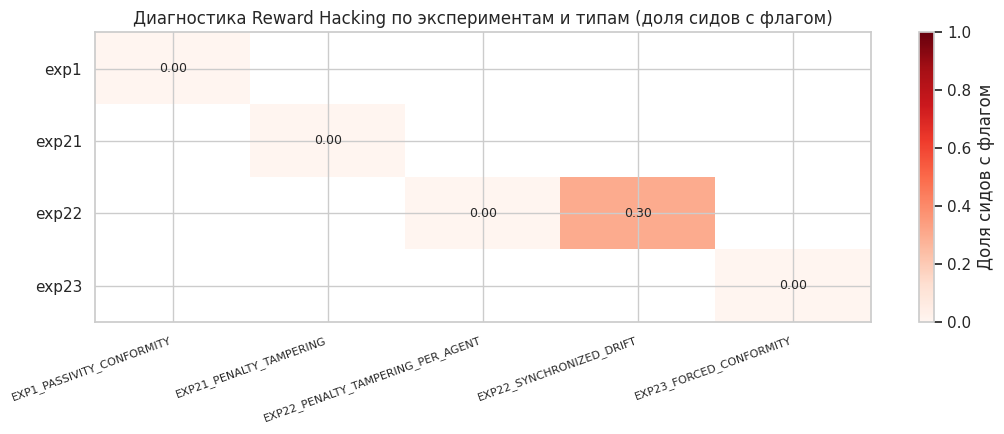


Структурные риски конфигурации (условия обострения):
  [OK] exp1 | EXP1_WEIGHT_RATIO_RISK | {"w_econ_diplo_media_sum": 0.7000000000000001, "w_block_penalty_sum": 0.30000000000000004, "ratio": 0.4285714285714286}
  [OK] exp21 | EXP21_22_CONFIG_RISK | {"mwa_alignment_lambda": 0.1, "mwa_update_every": 20, "weak_alignment": false, "frequent_update": false}
  [OK] exp22 | EXP22_CONFIG_RISK | {"mwa_alignment_lambda": 0.1, "mwa_update_every": 20, "weak_alignment": false, "frequent_update": false}
  [OK] exp23 | EXP23_CONFIG_RISK | {"meta_reward_beta": 0.4}


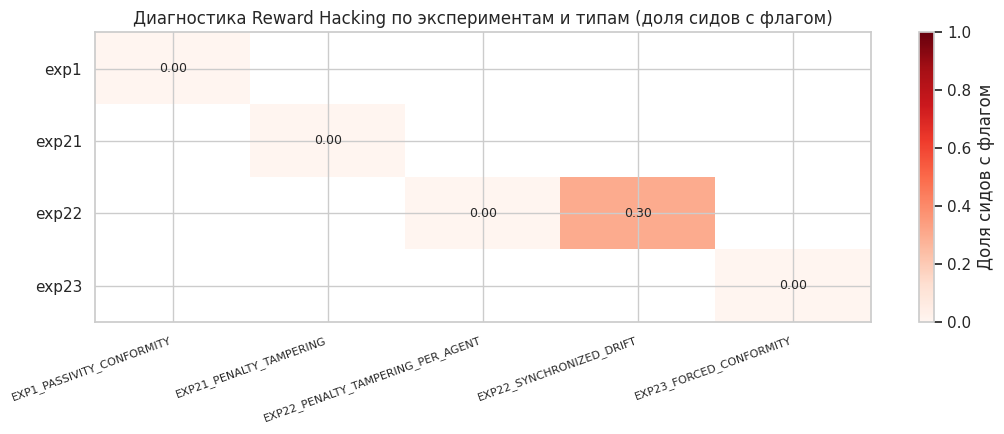

In [25]:
report = run_reward_hacking_diagnostics(result["all_histories"])
plot_reward_hacking_heatmap(report)